# Input-output properties cells

In [1]:
import numpy as np
import json
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# CircuitPath = 'O1_data_physiology/' # edges files not inclued in https://github.com/FernandoSBorges/NetPyNE_SONATA/tree/main/SCx_model/O1_data_physiology

CircuitPath = '/home/fernando/Dropbox/SUNY/2025/TACS/SCx_model/O1_data_physiology/'
Atlas = CircuitPath + 'atlas/'
Atlas2 = 'O1_data_physiology/voxel_atlas_data/'
MorphologyPath = CircuitPath + 'morphologies/ascii/'
nrnPath = CircuitPath + 'S1nonbarrel_neurons__S1nonbarrel_neurons__chemical/edges.h5'
CellLibraryFile = CircuitPath + 'S1nonbarrel_neurons/nodes.h5'
METypePath = CircuitPath + 'emodels_hoc/'

lst_properties = [ 'etype', 'exc_mini_frequency', 'inh_mini_frequency', 'layer', 'me_combo', 'model_template', 'model_type', 'morph_class', 'morphology', 'mtype', 
                  'orientation_w', 'orientation_x', 'orientation_y', 'orientation_z', 'population', 'region', 'synapse_class', '@dynamics:holding_current', 
                  '@dynamics:input_resistance', '@dynamics:resting_potential', '@dynamics:threshold_current', 'x', 'y', 'z']

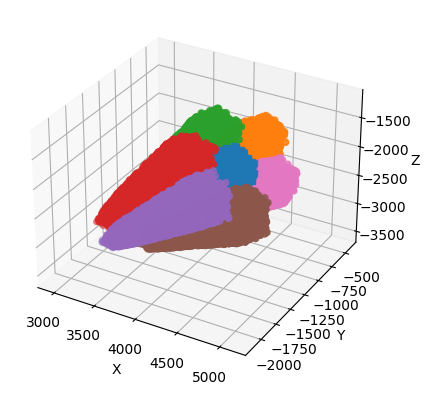

In [3]:
from bluepysnap import Circuit
from bluepysnap.bbp import Cell
circuit_path = CircuitPath + 'circuit_config.json'
circuit = Circuit(circuit_path)

cells = circuit.nodes["S1nonbarrel_neurons"]
proj_cells = circuit.nodes["external_S1nonbarrel_neurons__S1nonbarrel_neurons__chemical"]
cells_projections = proj_cells
nodesinfo = cells.get()
nodesinfo_projections = cells_projections.get()

In [4]:
nodesinfo[nodesinfo['layer'] == '4'].keys()

Index(['etype', 'exc_mini_frequency', 'hexagon', 'inh_mini_frequency', 'layer',
       'me_combo', 'model_template', 'model_type', 'morph_class', 'morphology',
       'mtype', 'orientation_w', 'orientation_x', 'orientation_y',
       'orientation_z', 'region', 'synapse_class', 'x', 'x_new', 'y', 'y_new',
       'z', 'z_new', '@dynamics:holding_current', '@dynamics:input_resistance',
       '@dynamics:resting_potential', '@dynamics:threshold_current'],
      dtype='object')

In [5]:
nodesinfo[nodesinfo['layer'] == '4'].head()

,etype,exc_mini_frequency,hexagon,inh_mini_frequency,layer,me_combo,model_template,model_type,morph_class,morphology,...,x,x_new,y,y_new,z,z_new,@dynamics:holding_current,@dynamics:input_resistance,@dynamics:resting_potential,@dynamics:threshold_current
node_ids,,,,,,,,,,,,,,,,,,,,,
108727,dSTUT,0.010108,2,0.233243,4,dSTUT_L4BP_L4_BP_4_C300797C-I1_-_Scale_x1.000_...,hoc:dSTUT_L4BP,biophysical,INT,C300797C-I1_-_Scale_x1.000_y0.975_z1.000_-_Clo...,...,3918.383222,345.100991,-882.079924,368.523207,-1946.094942,1431.980963,-0.048744,103.355850,-77.048584,0.092756
108728,bAC,0.010108,1,0.233243,4,bAC_L23BTC_L4_BP_4_rp140319_ChC_3_idA_-_Scale_...,hoc:bAC_L23BTC,biophysical,INT,rp140319_ChC_3_idA_-_Scale_x1.000_y0.975_z1.00...,...,4140.810336,179.239589,-766.305463,605.707003,-2090.662966,1435.342921,-0.011682,606.258118,-76.392754,0.024155
108729,cNAC,0.010108,0,0.233243,4,cNAC_L6NGC_L4_BP_4_C300797C-I1_-_Scale_x1.000_...,hoc:cNAC_L6NGC,biophysical,INT,C300797C-I1_-_Scale_x1.000_y0.950_z1.000_-_Clo...,...,3953.899058,722.166787,-1279.341226,593.262166,-2143.970161,1357.507449,-0.025396,385.013672,-74.105980,0.033770
108730,cACint,0.010108,0,0.233243,4,cACint_L4CHC_L4_BP_4_rp140319_ChC_3_idA_-_Scal...,hoc:cACint_L4CHC,biophysical,INT,rp140319_ChC_3_idA_-_Scale_x1.000_y0.975_z1.00...,...,4214.386218,740.411420,-1362.666051,842.778874,-2201.251811,1481.951494,-0.014442,636.180054,-73.075333,0.015156
108731,cACint,0.010108,0,0.233243,4,cACint_L4CHC_L4_BP_4_rp140319_ChC_3_idA_-_Scal...,hoc:cACint_L4CHC,biophysical,INT,rp140319_ChC_3_idA_-_Scale_x1.000_y1.025_z1.00...,...,4184.420803,714.604811,-1328.656268,916.399225,-2366.952165,1328.898361,-0.014949,620.984924,-72.957344,0.015535


In [6]:
# !nrnivmodl '/home/fernando/Dropbox/SUNY/2025/TACS/SCx_model/O1_data_physiology/mod/'

In [7]:
def distance3D(gidpre,gidpost):
    return np.sqrt(np.power(nodesinfo['x'][gidpre]-nodesinfo['x'][gidpost],2)+np.power(nodesinfo['y'][gidpre]-nodesinfo['y'][gidpost],2)+np.power(nodesinfo['z'][gidpre]-nodesinfo['z'][gidpost],2))

def distance2D(gidpre,gidpost):
    return np.sqrt(np.power(nodesinfo['x'][gidpre]-nodesinfo['x'][gidpost],2)+np.power(nodesinfo['y'][gidpre]-nodesinfo['y'][gidpost],2))

def distance2Dmean(gidpre, mean_x, mean_y):
    return np.sqrt(np.power(nodesinfo['x_new'][gidpre]-mean_x,2)+np.power(nodesinfo['y_new'][gidpre]-mean_y,2))

In [8]:
print(cells.property_values(Cell.REGION))

mtypes = sorted(cells.property_values(Cell.MTYPE))

i = 0
mntypes = {}
for mn in sorted(mtypes):
    mntypes[mn] = i
    i+=1

{'S1J', 'S1FL', 'S1DZ'}


## Select nodes to simulate

In [9]:
f = open('node_sets.json') 
node_sets = json.load(f) 

mean_x, mean_y = np.mean(nodesinfo['x_new']), np.mean(nodesinfo['y_new'])
node_gid = [] 
nodepremtype_new = []    
mtype_new = []     


node_gid = []
hoclist = []
Morpholist = []
node_threshold_current = []
node_holding_current = []


hex = 'hex0'
for gid in node_sets['hex0']['node_id']: 
# for gid in [117619, 142340, 142768, 142891, 141786,138337, 142077, 138315, 141829, 142671, 142352, 138475, 141536, 142859, 142058, 142814]: 
# for gid in [141766, 138220, 108767, 108729, 108749, 138433, 141757, 141803, 138337]: 
    if 'L4_' in nodesinfo['mtype'][gid] and distance2Dmean(gid, mean_x, mean_y) > 0.0 and distance2Dmean(gid, mean_x, mean_y) < 15.0 and 'EXC' in nodesinfo['synapse_class'][gid]:  
        nodepremtype_new.append(mntypes[nodesinfo['mtype'][gid]])
        if nodesinfo['mtype'][gid] not in mtype_new:
            mtype_new.append(nodesinfo['mtype'][gid])

        print(len(node_gid),gid,nodesinfo['synapse_class'][gid],nodesinfo['mtype'][gid],nodesinfo['model_template'][gid],nodesinfo['morphology'][gid],hex,distance2Dmean(gid, mean_x, mean_y))



        current1 = cells.get(gid,['@dynamics:threshold_current']).values[0]
        holding_current1 = cells.get(gid,['@dynamics:holding_current']).values[0]
        # print("%d %.5f %.5f" % (gid,current1,holding_current1))


        node_gid.append(gid)
        hoclist.append(nodesinfo['model_template'][gid][4:])
        Morpholist.append(nodesinfo['morphology'][gid])
        node_threshold_current.append(current1)
        node_holding_current.append(holding_current1)

            

# non central col
# for hex in node_sets['hex_O1']:
#     for gid in node_sets[hex]['node_id']:     
#         if 'L4' in nodesinfo['mtype'][gid] and distance2Dmean(gid, mean_x, mean_y) > 500.0 and distance2Dmean(gid, mean_x, mean_y) < 502.0:  
#             node_gid.append(gid)
#             nodepremtype_new.append(mntypes[nodesinfo['mtype'][gid]])
#             if nodesinfo['mtype'][gid] not in mtype_new:
#                 mtype_new.append(nodesinfo['mtype'][gid])

#             print(len(node_gid),gid,nodesinfo['mtype'][gid],hex,distance2Dmean(gid, mean_x, mean_y))        

0 109126 EXC L4_UPC hoc:cADpyr_L4TPC dend-C180997A-P3_axon-C031097B-P3 hex0 7.651331885081482
1 109632 EXC L4_UPC hoc:cADpyr_L4TPC dend-rp120608_P_3_idB_axon-vd110125B_INT_idA_-_Scale_x1.000_y1.050_z1.000 hex0 13.417897335385158
2 112531 EXC L4_UPC hoc:cADpyr_L4UPC dend-vd110125B_INT_idA_axon-rp120722_L4-1_idF_-_Scale_x1.000_y1.025_z1.000_-_Clone_0 hex0 13.071703743619349
3 114284 EXC L4_UPC hoc:cADpyr_L4UPC dend-rp120803_P_1_idB_axon-C031097B-P3_-_Scale_x1.000_y0.975_z1.000_-_Clone_0 hex0 3.667746548555403
4 114352 EXC L4_UPC hoc:cADpyr_L4UPC dend-mtC070301C_idB_axon-C180997A-P3_-_Scale_x1.000_y1.050_z1.000_-_Clone_0 hex0 13.017223842240734
5 115007 EXC L4_UPC hoc:cADpyr_L4UPC dend-C170898A-P4_axon-C031097B-P3_-_Scale_x1.000_y0.950_z1.000_-_Clone_0 hex0 0.9574206954055032
6 116011 EXC L4_UPC hoc:cADpyr_L4TPC dend-rp120521_P_1_idB_axon-rp120723_L4-2_idA_-_Scale_x1.000_y1.025_z1.000 hex0 11.099459107338411
7 117199 EXC L4_UPC hoc:cADpyr_L4TPC dend-rat_20160908_E3_LH2_cell3_axon-rp120608

In [10]:
mtype_new

['L4_UPC', 'L4_TPC', 'L4_SSC']

In [11]:
len(node_gid)
# hoclist = []
# Morpholist = []
# node_threshold_current = []
# node_holding_current = []

22

# Exploring the Lists

In [12]:
hoclist = sorted(cells.property_values(Cell.MODEL_TEMPLATE))
Morpholist = sorted(cells.property_values(Cell.MORPHOLOGY))
Mtypelist = sorted(cells.property_values(Cell.MTYPE))
Mtypelist[0:3], hoclist[0:3], Morpholist[0:3]

(['L1_DAC', 'L1_HAC', 'L1_LAC'],
 ['hoc:bAC_L23BTC', 'hoc:bAC_L6BTC', 'hoc:bIR_L23BP'],
 ['C010306C', 'C010306C_-_Clone_0', 'C010306C_-_Clone_1'])

# NetPyNE

In [13]:
from netpyne import specs, sim   

# Network parameters
netParams = specs.NetParams()  # object of class NetParams to store the network parameters

In [14]:
cellName_list = {}
cellName_list2 = []
gid_list = {}

    # if cellName not in cellName_list2:

cellName_list2 = []

for gid in node_gid:

    cellName = nodesinfo['mtype'][gid] + '_' + nodesinfo['etype'][gid] + '_' + nodesinfo['region'][gid][:3]
        
    cellName_list2.append(cellName)
    
    cellName_list[gid] = cellName + '_' + str(len(cellName_list2)-1)
    gid_list[cellName + '_' + str(len(cellName_list2)-1)] = gid
    
    print('%s \t %d' % (cellName + '_' + str(len(cellName_list2)-1),gid))

L4_UPC_cADpyr_S1F_0 	 109126
L4_UPC_cADpyr_S1F_1 	 109632
L4_UPC_cADpyr_S1F_2 	 112531
L4_UPC_cADpyr_S1F_3 	 114284
L4_UPC_cADpyr_S1F_4 	 114352
L4_UPC_cADpyr_S1F_5 	 115007
L4_UPC_cADpyr_S1F_6 	 116011
L4_UPC_cADpyr_S1F_7 	 117199
L4_TPC_cADpyr_S1F_8 	 118008
L4_TPC_cADpyr_S1F_9 	 118551
L4_TPC_cADpyr_S1F_10 	 118903
L4_TPC_cADpyr_S1F_11 	 125451
L4_TPC_cADpyr_S1F_12 	 131862
L4_TPC_cADpyr_S1F_13 	 132504
L4_TPC_cADpyr_S1F_14 	 133289
L4_TPC_cADpyr_S1F_15 	 133293
L4_TPC_cADpyr_S1F_16 	 133426
L4_TPC_cADpyr_S1F_17 	 135956
L4_TPC_cADpyr_S1F_18 	 137858
L4_SSC_cADpyr_S1F_19 	 139754
L4_SSC_cADpyr_S1F_20 	 141213
L4_SSC_cADpyr_S1F_21 	 141369


In [15]:
gid_list

{'L4_UPC_cADpyr_S1F_0': 109126,
 'L4_UPC_cADpyr_S1F_1': 109632,
 'L4_UPC_cADpyr_S1F_2': 112531,
 'L4_UPC_cADpyr_S1F_3': 114284,
 'L4_UPC_cADpyr_S1F_4': 114352,
 'L4_UPC_cADpyr_S1F_5': 115007,
 'L4_UPC_cADpyr_S1F_6': 116011,
 'L4_UPC_cADpyr_S1F_7': 117199,
 'L4_TPC_cADpyr_S1F_8': 118008,
 'L4_TPC_cADpyr_S1F_9': 118551,
 'L4_TPC_cADpyr_S1F_10': 118903,
 'L4_TPC_cADpyr_S1F_11': 125451,
 'L4_TPC_cADpyr_S1F_12': 131862,
 'L4_TPC_cADpyr_S1F_13': 132504,
 'L4_TPC_cADpyr_S1F_14': 133289,
 'L4_TPC_cADpyr_S1F_15': 133293,
 'L4_TPC_cADpyr_S1F_16': 133426,
 'L4_TPC_cADpyr_S1F_17': 135956,
 'L4_TPC_cADpyr_S1F_18': 137858,
 'L4_SSC_cADpyr_S1F_19': 139754,
 'L4_SSC_cADpyr_S1F_20': 141213,
 'L4_SSC_cADpyr_S1F_21': 141369}

In [16]:
cellsList = {}

for cellName in sorted(gid_list.keys()):
    
    gid = gid_list[cellName]

    # MorphoName = nodesinfo['morphology'][gid] + '.asc'

    hocName = nodesinfo['model_template'][gid][4:]  

    MorphologyPath = '/home/fernando/Dropbox/SUNY/2025/TACS/SCx_model/O1_data_physiology/morphologies2/ascii/'
    
    MorphoName = nodesinfo['morphology'][gid]+"_gid"+str(gid)+".asc"

    print(cellName,hocName)
        
    cellRule = netParams.importCellParams(label=cellName, somaAtOrigin=True,
        conds={'cellType': cellName, 'cellModel': 'HH_full'},
        fileName='/home/fernando/Dropbox/SUNY/2025/TACS/SCx_model/O1_data_physiology/emodels_hoc2/' + hocName + '.hoc',
        cellName=hocName,
        cellInstance = False,
        cellArgs=[gid, MorphologyPath, MorphoName])
    

    mechs_pas = netParams.cellParams[cellName]['secs']['soma_0']['mechs']['pas']

    for axx in netParams.cellParams[cellName]['secLists']['axonal'][3:]:
        del netParams.cellParams[cellName]['secs'][axx]['mechs']
        netParams.cellParams[cellName]['secs'][axx]['mechs'] = {}
        netParams.cellParams[cellName]['secs'][axx]['mechs']['pas'] = mechs_pas
        netParams.cellParams[cellName]['secs'][axx]['geom']['cm'] = 0.02
        netParams.cellParams[cellName]['secs'][axx]['geom']['nseg'] = 1
    
    # netParams.cellParams[cellName]['secs']['axon_0']['geom']['diam'] = 1.0
    
    print(netParams.cellParams[cellName]['secLists']['axonal'][-1])

    # for axx in netParams.cellParams[cellName]['secLists']['axonal'][:5]:
    #     print(axx,netParams.cellParams[cellName]['secs'][axx]['topol'],netParams.cellParams[cellName]['secs'][axx]['geom']['L'],netParams.cellParams[cellName]['secs'][axx]['geom']['diam']) 
        
    # for axx in netParams.cellParams[cellName]['secLists']['basal'][:5]:
    #     print(axx,netParams.cellParams[cellName]['secs'][axx]['topol'],netParams.cellParams[cellName]['secs'][axx]['geom']['L'],netParams.cellParams[cellName]['secs'][axx]['geom']['diam']) 
        
    # for axx in netParams.cellParams[cellName]['secLists']['apical'][:5]:
    #     print(axx,netParams.cellParams[cellName]['secs'][axx]['topol'],netParams.cellParams[cellName]['secs'][axx]['geom']['L'],netParams.cellParams[cellName]['secs'][axx]['geom']['diam']) 
        
    # netParams.cellParams[cellName]['secs']['axon_0']['geom']['L'] = 30.0
    # netParams.cellParams[cellName]['secs']['axon_1']['geom']['L'] = 30.0
    # netParams.cellParams[cellName]['secs']['axon_2']['geom']['L'] = 30.0
    
    # netParams.cellParams[cellName]['secs']['axon_1']['geom']['diam'] = 0.5
    # netParams.cellParams[cellName]['secs']['axon_2']['geom']['diam'] = 0.5
    # print(netParams.cellParams[cellName]['secs']['axon_3'])

    cellsList[cellName] = [{'x': nodesinfo['x'][gid], 'y': nodesinfo['y'][gid], 'z': nodesinfo['z'][gid]}]
    # cellsList[cellName] = [{'x': nodesinfo['x'][gid] - 3000.0, 'y': nodesinfo['y'][gid] + 2000.0, 'z': nodesinfo['z'][gid] + 3500.0}]
    
# cellsList


L4_SSC_cADpyr_S1F_19 cADpyr_L4TPC
axon_106
L4_SSC_cADpyr_S1F_20 cADpyr_L4TPC
axon_116
L4_SSC_cADpyr_S1F_21 cADpyr_L4TPC
axon_102
L4_TPC_cADpyr_S1F_10 cADpyr_L4TPC
axon_84
L4_TPC_cADpyr_S1F_11 cADpyr_L4UPC
axon_148
L4_TPC_cADpyr_S1F_12 cADpyr_L4UPC
axon_150
L4_TPC_cADpyr_S1F_13 cADpyr_L4TPC
axon_52
L4_TPC_cADpyr_S1F_14 cADpyr_L4TPC
axon_114
L4_TPC_cADpyr_S1F_15 cADpyr_L4UPC
axon_124
L4_TPC_cADpyr_S1F_16 cADpyr_L4TPC
axon_95
L4_TPC_cADpyr_S1F_17 cADpyr_L4TPC
axon_50
L4_TPC_cADpyr_S1F_18 cADpyr_L4TPC
axon_88
L4_TPC_cADpyr_S1F_8 cADpyr_L4TPC
axon_52
L4_TPC_cADpyr_S1F_9 cADpyr_L4UPC
axon_87
L4_UPC_cADpyr_S1F_0 cADpyr_L4TPC
axon_60
L4_UPC_cADpyr_S1F_1 cADpyr_L4TPC
axon_80
L4_UPC_cADpyr_S1F_2 cADpyr_L4UPC
axon_112
L4_UPC_cADpyr_S1F_3 cADpyr_L4UPC
axon_60
L4_UPC_cADpyr_S1F_4 cADpyr_L4UPC
axon_48
L4_UPC_cADpyr_S1F_5 cADpyr_L4UPC
axon_60
L4_UPC_cADpyr_S1F_6 cADpyr_L4TPC
axon_100
L4_UPC_cADpyr_S1F_7 cADpyr_L4TPC
axon_54


In [17]:
netParams.cellParams[cellName]['secs'][axx]['geom']['nseg']

1

In [18]:
netParams.cellParams[cellName]['secs']['soma_0']['mechs']

{CaDynamics_DC0: {gamma: 0.039103439855754166, decay: 161.8376197724567}, Ca_HVA2: {gCa_HVAbar: 0.00023353533920927655}, Ca_LVAst: {gCa_LVAstbar: 0.0035324057416009475}, Ih: {gIhbar: 7.536873819912383e-05}, K_Pst: {gK_Pstbar: 0.1355737213804932}, K_Tst: {gK_Tstbar: 0.008826685327690785}, NaTg: {gNaTgbar: 0.098311490036494, vshifth: 15.0, vshiftm: 13.0, slopeh: 6.0, slopem: 7.0}, SK_E2: {gSK_E2bar: 0.026986028072569477, zTau: 1.0}, SKv3_1: {gSKv3_1bar: 0.23801720189545422}, pas: {g: 4.252927638565983e-05, e: -82.20245012035248}, _repr_mimebundle_: {}}

In [19]:
netParams.cellParams[cellName]['secs']['axon_0']['mechs']

{CaDynamics_DC0: {gamma: 0.012205254378638739, decay: 296.2027610799689}, Ca_HVA2: {gCa_HVAbar: 0.0005978773780190565}, Ca_LVAst: {gCa_LVAstbar: 0.0011909469272548526}, K_Pst: {gK_Pstbar: 0.7696010845010367}, K_Tst: {gK_Tstbar: 0.0817247808041021}, NaTg: {gNaTgbar: 0.6117240305095417, vshifth: 10.0, vshiftm: 0.0, slopeh: 6.0, slopem: 9.0}, Nap_Et2: {gNap_Et2bar: 0.007849507096255301}, SK_E2: {gSK_E2bar: 0.004079456770544682, zTau: 1.0}, SKv3_1: {gSKv3_1bar: 0.43997985764050956}, pas: {g: 4.252927638565983e-05, e: -82.20245012035248}, _repr_mimebundle_: {}}

In [20]:
netParams.cellParams[cellName]['secs']['axon_1']['mechs']

{CaDynamics_DC0: {gamma: 0.012205254378638739, decay: 296.2027610799689}, Ca_HVA2: {gCa_HVAbar: 0.0005978773780190565}, Ca_LVAst: {gCa_LVAstbar: 0.0011909469272548526}, K_Pst: {gK_Pstbar: 0.7696010845010367}, K_Tst: {gK_Tstbar: 0.0817247808041021}, NaTg: {gNaTgbar: 0.6117240305095417, vshifth: 10.0, vshiftm: 0.0, slopeh: 6.0, slopem: 9.0}, Nap_Et2: {gNap_Et2bar: 0.007849507096255301}, SK_E2: {gSK_E2bar: 0.004079456770544682, zTau: 1.0}, SKv3_1: {gSKv3_1bar: 0.43997985764050956}, pas: {g: 4.252927638565983e-05, e: -82.20245012035248}, _repr_mimebundle_: {}}

In [21]:
netParams.cellParams[cellName]['secs']['axon_2']['mechs']

{CaDynamics_DC0: {gamma: 0.012205254378638739, decay: 296.2027610799689}, Ca_HVA2: {gCa_HVAbar: 0.0005978773780190565}, Ca_LVAst: {gCa_LVAstbar: 0.0011909469272548526}, K_Pst: {gK_Pstbar: 0.7696010845010367}, K_Tst: {gK_Tstbar: 0.0817247808041021}, NaTg: {gNaTgbar: 0.6117240305095417, vshifth: 10.0, vshiftm: 0.0, slopeh: 6.0, slopem: 9.0}, Nap_Et2: {gNap_Et2bar: 0.007849507096255301}, SK_E2: {gSK_E2bar: 0.004079456770544682, zTau: 1.0}, SKv3_1: {gSKv3_1bar: 0.43997985764050956}, pas: {g: 4.252927638565983e-05, e: -82.20245012035248}, _repr_mimebundle_: {}}

In [22]:
netParams.cellParams[cellName]['secs']['axon_3']['mechs']

{'pas': {g: 4.252927638565983e-05, e: -82.20245012035248}}

In [23]:
# netParams.cellParams[cellName]
for cellName in netParams.cellParams.keys():    
    netParams.popParams[cellName] = {'cellType': cellName, 'cellsList': cellsList[cellName], 'cellModel': 'HH_full'}

In [24]:
netParams.popParams.keys()

odict_keys(['L4_SSC_cADpyr_S1F_19', 'L4_SSC_cADpyr_S1F_20', 'L4_SSC_cADpyr_S1F_21', 'L4_TPC_cADpyr_S1F_10', 'L4_TPC_cADpyr_S1F_11', 'L4_TPC_cADpyr_S1F_12', 'L4_TPC_cADpyr_S1F_13', 'L4_TPC_cADpyr_S1F_14', 'L4_TPC_cADpyr_S1F_15', 'L4_TPC_cADpyr_S1F_16', 'L4_TPC_cADpyr_S1F_17', 'L4_TPC_cADpyr_S1F_18', 'L4_TPC_cADpyr_S1F_8', 'L4_TPC_cADpyr_S1F_9', 'L4_UPC_cADpyr_S1F_0', 'L4_UPC_cADpyr_S1F_1', 'L4_UPC_cADpyr_S1F_2', 'L4_UPC_cADpyr_S1F_3', 'L4_UPC_cADpyr_S1F_4', 'L4_UPC_cADpyr_S1F_5', 'L4_UPC_cADpyr_S1F_6', 'L4_UPC_cADpyr_S1F_7'])

## Net info

In [25]:
print(list(circuit.nodes))
print(list(circuit.edges))

['POm', 'S1nonbarrel_neurons', 'VPM', 'external_S1nonbarrel_neurons__S1nonbarrel_neurons__chemical']
['POm__S1nonbarrel_neurons__chemical', 'S1nonbarrel_neurons__S1nonbarrel_neurons__chemical', 'VPM__S1nonbarrel_neurons__chemical', 'external_S1nonbarrel_neurons__S1nonbarrel_neurons__chemical']


In [26]:
cells = circuit.nodes["S1nonbarrel_neurons"]
conn = circuit.edges["S1nonbarrel_neurons__S1nonbarrel_neurons__chemical"]

proj_cells = circuit.nodes["external_S1nonbarrel_neurons__S1nonbarrel_neurons__chemical"]
proj_conn = circuit.edges["external_S1nonbarrel_neurons__S1nonbarrel_neurons__chemical"]
print(cells.size)
print(conn.size)
print(proj_cells.size)
print(proj_conn.size)

211712
406836913
549126
104319446


### Synaptic connectivity

The synaptic connectivity of the model is accessed using circ_extr.edges.
As an example, let's find out which neurons innervate an exemplary neuron

In [27]:
var_list_a = ['@source_node','@target_node','conductance','conductance_scale_factor','decay_time','delay','depression_time',
                'facilitation_time','n_rrp_vesicles','spine_length','syn_type_id','u_hill_coefficient','u_syn', 
                'afferent_section_id', 'afferent_section_type', 'afferent_segment_id','efferent_section_id', 'efferent_section_type', 'efferent_segment_id']
list_pre = []

for gid2 in node_gid:
# afferent edges of node_ids[gid2]
    sampled_edge_ids = conn.afferent_edges(gid2)
    
    var_list_a = sorted(conn.property_names)
    
    connsinfo = conn.get(sampled_edge_ids,var_list_a)
    
    unique, counts = np.unique(list(connsinfo['@source_node'].values), return_counts=True)
    # unique, counts 
    synNumber = dict(zip(unique, counts))
    # synNumber
    
    for gid in node_gid:
        try:
            print("gid =",gid, cellName_list[gid], "\t coonected with \t gid =",gid2,cellName_list[gid2],'\t with',synNumber[gid], 'connections',
                  list([netParams.cellParams[cellName_list[gid]]['secLists']['all'][isecN] for isecN in connsinfo.get(connsinfo['@source_node']==gid)['efferent_section_id'].values]),
                  list([netParams.cellParams[cellName_list[gid2]]['secLists']['all'][isecN] for isecN in connsinfo.get(connsinfo['@source_node']==gid)['afferent_section_id'].values]))


            synType = connsinfo.get(connsinfo['@source_node']==gid)['syn_type_id'].values[0]

            if synType > 99:

                print("EXC -> gid =",gid, cellName_list[gid],"synType =",synType)

                netParams.synMechParams[cellName_list[gid]+'->'+cellName_list[gid2]] = {'mod': 'ProbAMPANMDA_EMS',
                                            'Dep': connsinfo.get(connsinfo['@source_node']==gid)['depression_time'].values[0],
                                            'Fac': connsinfo.get(connsinfo['@source_node']==gid)['facilitation_time'].values[0],
                                            'Use': connsinfo.get(connsinfo['@source_node']==gid)['u_syn'].values[0]/connsinfo.get(connsinfo['@source_node']==gid)['u_hill_coefficient'].values[0],
                                            'tau_d_AMPA': connsinfo.get(connsinfo['@source_node']==gid)['decay_time'].values[0],
                                            'NMDA_ratio':0.8,
                                            # 'Nrrp':connsinfo.get(connsinfo['@source_node']==gid)['n_rrp_vesicles'].values[0],
                                            }            
            else:

                print("INH -> gid =",gid, cellName_list[gid],"synType =",synType)                

                netParams.synMechParams[cellName_list[gid]+'->'+cellName_list[gid2]] = {'mod': 'ProbGABAAB_EMS',
                                            'Dep': connsinfo.get(connsinfo['@source_node']==gid)['depression_time'].values[0],
                                            'Fac': connsinfo.get(connsinfo['@source_node']==gid)['facilitation_time'].values[0],
                                            'Use': connsinfo.get(connsinfo['@source_node']==gid)['u_syn'].values[0]/connsinfo.get(connsinfo['@source_node']==gid)['u_hill_coefficient'].values[0],
                                            'tau_d_GABAA': connsinfo.get(connsinfo['@source_node']==gid)['decay_time'].values[0],
                                            'GABAB_ratio':0.0,
                                            # 'Nrrp':connsinfo.get(connsinfo['@source_node']==gid)['n_rrp_vesicles'].values[0], # new ProbGABAAB_EMS.mod not working, using 2015 version without 'Nrrp'
                                            }
                
            print(netParams.synMechParams[cellName_list[gid]+'->'+cellName_list[gid2]])


            netParams.connParams[cellName_list[gid]+'->'+cellName_list[gid2]] = { 
                        'preConds': {'pop': cellName_list[gid]},
                        'postConds': {'pop': cellName_list[gid2]},
                        'connList': [[0,0] for ii in range(len(connsinfo.get(connsinfo['@source_node']==gid)))],
                        'sec': list([netParams.cellParams[cellName_list[gid2]]['secLists']['all'][isecN] for isecN in connsinfo.get(connsinfo['@source_node']==gid)['afferent_section_id'].values]),                  # target postsyn section
                        'synMech': cellName_list[gid]+'->'+cellName_list[gid2],              # target synaptic mechanism
                        'weight': list(1.0*connsinfo.get(connsinfo['@source_node']==gid)['conductance'].values*connsinfo.get(connsinfo['@source_node']==gid)['conductance_scale_factor'].values[0]),                 # synaptic weight 
                        'delay':list(connsinfo.get(connsinfo['@source_node']==gid)['delay'].values),                 # synaptic delay 
                        # 'loc':list(connsinfo.get(connsinfo['@source_node']==gid)['afferent_section_pos'].values), # error only to plotShape syn positions
                        }    
                
            print(netParams.connParams[cellName_list[gid]+'->'+cellName_list[gid2]]) 
            
            if gid not in list_pre:
                list_pre.append(gid)
                
            print(connsinfo.get(connsinfo['@source_node']==gid)['conductance'].values[0],connsinfo.get(connsinfo['@source_node']==gid)['conductance_scale_factor'].values[0],
                  connsinfo.get(connsinfo['@source_node']==gid)['u_syn'].values[0],connsinfo.get(connsinfo['@source_node']==gid)['u_hill_coefficient'].values[0],
                  connsinfo.get(connsinfo['@source_node']==gid)['depression_time'].values[0],connsinfo.get(connsinfo['@source_node']==gid)['facilitation_time'].values[0],
                  connsinfo.get(connsinfo['@source_node']==gid)['decay_time'].values[0],connsinfo.get(connsinfo['@source_node']==gid)['n_rrp_vesicles'].values[0],
                  )
            print()
        except:
            pass #print(gid,cellName_list[gid], "\tnot coonected with \t gid =",gid2,cellName_list[gid2])

gid = 137858 L4_TPC_cADpyr_S1F_18 	 coonected with 	 gid = 109126 L4_UPC_cADpyr_S1F_0 	 with 7 connections ['axon_64', 'axon_64', 'axon_73', 'axon_73', 'axon_73', 'axon_73', 'axon_88'] ['apic_37', 'dend_3', 'apic_1', 'apic_7', 'apic_7', 'apic_7', 'dend_13']
EXC -> gid = 137858 L4_TPC_cADpyr_S1F_18 synType = 100
{'mod': 'ProbAMPANMDA_EMS', 'Dep': 678.212158203125, 'Fac': 20.90871810913086, 'Use': 0.32488725091394133, 'tau_d_AMPA': 1.837368130683899, 'NMDA_ratio': 0.8}
{'preConds': {'pop': 'L4_TPC_cADpyr_S1F_18'}, 'postConds': {'pop': 'L4_UPC_cADpyr_S1F_0'}, 'connList': [[0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0]], 'sec': ['apic_37', 'dend_3', 'apic_1', 'apic_7', 'apic_7', 'apic_7', 'dend_13'], 'synMech': 'L4_TPC_cADpyr_S1F_18->L4_UPC_cADpyr_S1F_0', 'weight': [0.4981031572818756, 0.4981031572818756, 0.4981031572818756, 0.4981031572818756, 0.4981031572818756, 0.4981031572818756, 0.4981031572818756], 'delay': [0.985217, 1.0675921, 0.7540466, 0.8450576, 0.8649072, 0.8876331, 0.9

{'preConds': {'pop': 'L4_SSC_cADpyr_S1F_20'}, 'postConds': {'pop': 'L4_UPC_cADpyr_S1F_0'}, 'connList': [[0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0]], 'sec': ['dend_9', 'dend_1', 'apic_33', 'dend_34', 'dend_34', 'dend_34', 'dend_20', 'apic_14'], 'synMech': 'L4_SSC_cADpyr_S1F_20->L4_UPC_cADpyr_S1F_0', 'weight': [0.48140157461166383, 0.48140157461166383, 0.48140157461166383, 0.48140157461166383, 0.48140157461166383, 0.48140157461166383, 0.48140157461166383, 0.48140157461166383], 'delay': [1.4926795, 1.5039573, 1.5324941, 0.8468675, 0.85793746, 0.85676706, 0.9617347, 0.79544336]}
0.5597692728042603 0.86 0.8017043471336365 2.79 707.247802734375 13.103675842285156 1.5761349201202393 1

gid = 133289 L4_TPC_cADpyr_S1F_14 	 coonected with 	 gid = 109632 L4_UPC_cADpyr_S1F_1 	 with 9 connections ['axon_3', 'axon_3', 'axon_3', 'axon_3', 'axon_3', 'axon_3', 'axon_5', 'axon_63', 'axon_86'] ['dend_38', 'dend_38', 'dend_38', 'dend_38', 'dend_38', 'dend_38', 'dend_22', 'dend_15', 'de

In [28]:
var_list_a = ['@source_node','@target_node',
            #   'conductance','conductance_scale_factor','decay_time','delay','depression_time',
                # 'facilitation_time','n_rrp_vesicles','spine_length','syn_type_id','u_hill_coefficient','u_syn', 
                'afferent_section_id', 'afferent_section_type', 'afferent_segment_id','efferent_section_id', 'efferent_section_type', 'efferent_segment_id']

gid = 141655
gid2 = 138260
# afferent edges of node_ids[gid2]
sampled_edge_ids = conn.afferent_edges(gid2)    
# var_list_a = sorted(conn.property_names)[0:12]    
connsinfo = conn.get(sampled_edge_ids,var_list_a)
connsinfo.get(connsinfo['@source_node']==gid)

,@source_node,@target_node,afferent_section_id,afferent_section_type,afferent_segment_id,efferent_section_id,efferent_section_type,efferent_segment_id
221892569,141655,138260,550,3,0,0,0,0
221892570,141655,138260,550,3,0,0,0,0
221892571,141655,138260,556,3,0,0,0,0
221892572,141655,138260,550,3,0,0,0,0
221892573,141655,138260,549,3,0,0,0,0
221892574,141655,138260,555,3,0,0,0,0
221892575,141655,138260,566,3,0,0,0,0
221892576,141655,138260,550,3,0,0,0,0
221892577,141655,138260,549,3,0,0,0,0
221892578,141655,138260,571,3,0,0,0,0


In [29]:
list_pre

[137858,
 141213,
 133289,
 133426,
 141369,
 109126,
 109632,
 112531,
 131862,
 133293,
 135956,
 117199,
 118903,
 118551,
 118008,
 139754]

In [30]:
for gid in node_gid: # list_pre:

    popName1 = cellName_list[gid]
    current1 = 2.5*cells.get(gid,['@dynamics:threshold_current']).values[0]
    holding_current1 = cells.get(gid,['@dynamics:holding_current']).values[0]

    current1 = 0.8
    holding_current1 = 0.0

    netParams.stimSourceParams['Input_'+str(gid)] = {'type': 'IClamp', 'del': 0.0, 'dur': 600.0, 'amp': holding_current1}
    netParams.stimSourceParams['Inputb_'+str(gid)] = {'type': 'IClamp', 'del': 300.0, 'dur': 600.0, 'amp':current1}

    netParams.stimTargetParams['Input->'+str(gid)] = {'source': 'Input_'+str(gid), 'sec':'soma_0', 'loc': 0.5, 'conds': {'pop':popName1}}
    netParams.stimTargetParams['Inputb->'+str(gid)] = {'source': 'Inputb_'+str(gid), 'sec':'soma_0', 'loc': 0.5, 'conds': {'pop':popName1}}

In [31]:
#------------------------------------------------------------------------------
# General network parameters
#------------------------------------------------------------------------------
netParams.scale = 1.0 # Scale factor for number of cells
netParams.sizeX = 420.0 # x-dimension (horizontal length) size in um
netParams.sizeY = 500.0 # y-dimension (vertical height or cortical depth) size in um
netParams.sizeZ = 420.0 # z-dimension (horizontal depth) size in um
netParams.shape = 'cylinder' # cylindrical (column-like) volume
   
netParams.defaultThreshold = -20.0 # spike threshold, 10 mV is NetCon default, lower it for all cells
    

In [32]:
#------------------------------------------------------------------------------
#
# SIMULATION CONFIGURATION
#
#------------------------------------------------------------------------------

cfg = specs.SimConfig()					            # object of class SimConfig to store simulation configuration

cfg.coreneuron = False

#------------------------------------------------------------------------------
# Run parameters
#------------------------------------------------------------------------------
cfg.duration = 1.0*1e3 ## Duration of the sim, in ms  
cfg.dt = 0.025
cfg.seeds = {'conn': 4321, 'stim': 1000, 'loc': 4321} 
cfg.hParams = {'celsius': 34, 'v_init': -84.0}  
cfg.verbose = False
cfg.createNEURONObj = True
cfg.createPyStruct = True  
cfg.cvode_active = False
cfg.cvode_atol = 1e-6
cfg.cache_efficient = True
cfg.printRunTime = 0.1

cfg.includeParamsLabel = False
cfg.printPopAvgRates = True
cfg.checkErrors = False

#--------------------------------------------------------------------------
# Recording 
#--------------------------------------------------------------------------
# cfg.recordTraces = {'V_soma': {'sec':'soma_0', 'loc':0.5, 'var':'v'}}  ## Dict with traces to record  
cfg.recordTraces = {'V_soma': {'sec':'soma_0', 'loc':0.5, 'var':'v'},
                    # 'V_axon_0': {'sec':'axon_0', 'loc':0.5, 'var':'v'},
                    # 'V_axon_1': {'sec':'axon_1', 'loc':0.5, 'var':'v'},
                    # 'V_axon_20': {'sec':'axon_20', 'loc':0.5, 'var':'v'},
                    # 'V_axon_30': {'sec':'axon_30', 'loc':0.5, 'var':'v'},
                    # 'V_axon_40': {'sec':'axon_40', 'loc':0.5, 'var':'v'},
                    # 'V_axon_5': {'sec':'axon_5', 'loc':0.5, 'var':'v'},
                    # 'V_axon_6': {'sec':'axon_6', 'loc':0.5, 'var':'v'},
                    # 'V_apic_0': {'sec':'apic_0', 'loc':0.5, 'var':'v'},
                    # 'V_apic_47': {'sec':'apic_47', 'loc':0.5, 'var':'v'},       
                    # 'V_apic_64': {'sec':'apic_64', 'loc':0.5, 'var':'v'},
                    # 'V_apic_86': {'sec':'apic_86', 'loc':0.5, 'var':'v'},           
                    # 'V_dend_0': {'sec':'dend_0', 'loc':0.5, 'var':'v'},       
                    # 'V_dend_15': {'sec':'dend_15', 'loc':0.5, 'var':'v'},
                    }
cfg.recordStim = False			
cfg.recordTime = False  		
cfg.recordStep = 0.025       

#------------------------------------------------------------------------------
# Saving
#------------------------------------------------------------------------------
cfg.simLabel = 'v0_batch0'       #   + str(cfg.cynradNumber)
cfg.saveFolder = 'exploration/data/'+cfg.simLabel
# cfg.filename =                	## Set file output name
cfg.savePickle = False	        	## Save pkl file
cfg.saveJson = False           	## Save json file
cfg.saveDataInclude = ['simData', 'simConfig', 'net', 'netParams'] ## ['simData'] ##  ['simData'] ##, , 'simConfig', 'netParams'
cfg.backupCfgFile = None 		##  
cfg.gatherOnlySimData = False	##  
cfg.saveCellSecs = True			
cfg.saveCellConns = True	

#------------------------------------------------------------------------------
# Analysis and plotting 
# ------------------------------------------------------------------------------
# cfg.analysis['plotRaster'] = {'include': cfg.S1cells, 'saveFig': True, 'showFig': False,'orderInverse': True, 'timeRange': [0,cfg.duration], 'figSize': (24,8), 'fontSize':4, 'markerSize':4, 'marker': 'o', 'dpi': 300} 
# cfg.analysis['plot2Dnet']   = {'include': ['presyn_L23_PC_cAD','presyn_L5_TTPC2_cAD', 'presyn_VPM_sTC','L23_PC_cAD','L5_TTPC2_cAD'],'saveFig': True, 'showConns': False, 'figSize': (24,24), 'view': 'xz', 'fontSize':16}   # Plot 2D cells xy
# cfg.analysis['plotTraces'] = {'include': cfg.recordCells, 'oneFigPer': 'trace', 'overlay': True, 'timeRange': [0,cfg.duration], 'ylim': [-100,50], 'saveFig': True, 'showFig': False, 'figSize':(24,24)}

cfg.analysis['plotTraces'] = {'include': [ii for ii in range(len(node_gid))], 'oneFigPer': 'trace', 'overlay': True, 'timeRange': [0,cfg.duration], 'saveFig': False, 'showFig': True, 'figSize':(24,4)} # , 'ylim': [-90,30] Plot recorded traces for this list of cells
# cfg.analysis['plotShape'] = {'includePre':  [ii for ii in range(10)],'includePre':  [ii for ii in range(10)], 'saveFig': True, 'showFig': True, 'figSize':(12,12)}

In [33]:
cfg.invertedYCoord = False

In [34]:
sim.initialize(
    simConfig = cfg, 	
    netParams = netParams)  				# create network object and set cfg and net params
sim.net.createPops()               			# instantiate network populations


Start time:  2025-03-14 15:16:07.581038


{L4_SSC_cADpyr_S1F_19: <netpyne.network.pop.Pop object at 0x78b000f86e80>, L4_SSC_cADpyr_S1F_20: <netpyne.network.pop.Pop object at 0x78b048202940>, L4_SSC_cADpyr_S1F_21: <netpyne.network.pop.Pop object at 0x78b03dfde0a0>, L4_TPC_cADpyr_S1F_10: <netpyne.network.pop.Pop object at 0x78b000e0c220>, L4_TPC_cADpyr_S1F_11: <netpyne.network.pop.Pop object at 0x78b000e0cb20>, L4_TPC_cADpyr_S1F_12: <netpyne.network.pop.Pop object at 0x78b000e0c460>, L4_TPC_cADpyr_S1F_13: <netpyne.network.pop.Pop object at 0x78b000e0ccd0>, L4_TPC_cADpyr_S1F_14: <netpyne.network.pop.Pop object at 0x78b003ebb040>, L4_TPC_cADpyr_S1F_15: <netpyne.network.pop.Pop object at 0x78b003ebb2e0>, L4_TPC_cADpyr_S1F_16: <netpyne.network.pop.Pop object at 0x78b003ebb580>, L4_TPC_cADpyr_S1F_17: <netpyne.network.pop.Pop object at 0x78b003ebb850>, L4_TPC_cADpyr_S1F_18: <netpyne.network.pop.Pop object at 0x78b003ebb970>, L4_TPC_cADpyr_S1F_8: <netpyne.network.pop.Pop object at 0x78b003ebbd30>, L4_TPC_cADpyr_S1F_9: <netpyne.network.

In [35]:
sim.net.createCells()              			# instantiate network cells based on defined populations


Creating network of 22 cell populations on 1 hosts...
ERROR: Some mechanisms and/or ions were not inserted (for details run with cfg.verbose=True). Make sure the required mod files are compiled.
  Number of cells on node 0: 22 
  Done; cell creation time = 1.09 s.


[compartCell_L4_SSC_cADpyr_S1F_19_HH_full_0,
 compartCell_L4_SSC_cADpyr_S1F_20_HH_full_1,
 compartCell_L4_SSC_cADpyr_S1F_21_HH_full_2,
 compartCell_L4_TPC_cADpyr_S1F_10_HH_full_3,
 compartCell_L4_TPC_cADpyr_S1F_11_HH_full_4,
 compartCell_L4_TPC_cADpyr_S1F_12_HH_full_5,
 compartCell_L4_TPC_cADpyr_S1F_13_HH_full_6,
 compartCell_L4_TPC_cADpyr_S1F_14_HH_full_7,
 compartCell_L4_TPC_cADpyr_S1F_15_HH_full_8,
 compartCell_L4_TPC_cADpyr_S1F_16_HH_full_9,
 compartCell_L4_TPC_cADpyr_S1F_17_HH_full_10,
 compartCell_L4_TPC_cADpyr_S1F_18_HH_full_11,
 compartCell_L4_TPC_cADpyr_S1F_8_HH_full_12,
 compartCell_L4_TPC_cADpyr_S1F_9_HH_full_13,
 compartCell_L4_UPC_cADpyr_S1F_0_HH_full_14,
 compartCell_L4_UPC_cADpyr_S1F_1_HH_full_15,
 compartCell_L4_UPC_cADpyr_S1F_2_HH_full_16,
 compartCell_L4_UPC_cADpyr_S1F_3_HH_full_17,
 compartCell_L4_UPC_cADpyr_S1F_4_HH_full_18,
 compartCell_L4_UPC_cADpyr_S1F_5_HH_full_19,
 compartCell_L4_UPC_cADpyr_S1F_6_HH_full_20,
 compartCell_L4_UPC_cADpyr_S1F_7_HH_full_21]

In [36]:
# sim.net.connectCells()            			# create connections between cells based on params

In [37]:
sim.net.addStims() 							# add network stimulation

Adding stims...
  Number of stims on node 0: 44 
  Done; cell stims creation time = 0.01 s.


[[{label: 'Input->139754', source: 'Input_139754', sec: 'soma_0', loc: 0.5, type: 'IClamp', del: 0.0, dur: 600.0, amp: 0.0, hObj: IClamp[38]},
  {label: 'Inputb->139754', source: 'Inputb_139754', sec: 'soma_0', loc: 0.5, type: 'IClamp', del: 300.0, dur: 600.0, amp: 0.8, hObj: IClamp[39]}],
 [{label: 'Input->141213', source: 'Input_141213', sec: 'soma_0', loc: 0.5, type: 'IClamp', del: 0.0, dur: 600.0, amp: 0.0, hObj: IClamp[40]},
  {label: 'Inputb->141213', source: 'Inputb_141213', sec: 'soma_0', loc: 0.5, type: 'IClamp', del: 300.0, dur: 600.0, amp: 0.8, hObj: IClamp[41]}],
 [{label: 'Input->141369', source: 'Input_141369', sec: 'soma_0', loc: 0.5, type: 'IClamp', del: 0.0, dur: 600.0, amp: 0.0, hObj: IClamp[42]},
  {label: 'Inputb->141369', source: 'Inputb_141369', sec: 'soma_0', loc: 0.5, type: 'IClamp', del: 300.0, dur: 600.0, amp: 0.8, hObj: IClamp[43]}],
 [{label: 'Input->118903', source: 'Input_118903', sec: 'soma_0', loc: 0.5, type: 'IClamp', del: 0.0, dur: 600.0, amp: 0.0, hOb

In [38]:
sim.setupRecording()              			# setup variables to record for each cell (spikes, V traces, etc)

Recording 22 traces of 1 types on node 0


{spkt: Vector[807110], spkid: Vector[807111], V_soma: {cell_0: Vector[807112], cell_1: Vector[807113], cell_2: Vector[807114], cell_3: Vector[807115], cell_4: Vector[807116], cell_5: Vector[807117], cell_6: Vector[807118], cell_7: Vector[807119], cell_8: Vector[807120], cell_9: Vector[807121], cell_10: Vector[807122], cell_11: Vector[807123], cell_12: Vector[807124], cell_13: Vector[807125], cell_14: Vector[807126], cell_15: Vector[807127], cell_16: Vector[807128], cell_17: Vector[807129], cell_18: Vector[807130], cell_19: Vector[807131], cell_20: Vector[807132], cell_21: Vector[807133]}, _repr_mimebundle_: {}}

In [39]:
sim.runSim()                      			# run parallel Neuron simulation  

0.0s

Running simulation using NEURON for 1000.0 ms...
0.1s
0.2s
0.3s
0.4s
0.5s
0.6s
0.7s
0.8s
0.9s
1.0s
  Done; run time = 81.31 s; real-time ratio: 0.01.


In [40]:
sim.gatherData();                  			# gather spiking data and cell info from each node


Gathering data...
  Done; gather time = 0.72 s.

Analyzing...
  Cells: 22
  Connections: 0 (0.00 per cell)
  Spikes: 530 (24.09 Hz)
  Simulated time: 1.0 s; 1 workers
  Run time: 81.31 s
   L4_SSC_cADpyr_S1F_19 : 32.000 Hz
   L4_SSC_cADpyr_S1F_20 : 31.000 Hz
   L4_SSC_cADpyr_S1F_21 : 32.000 Hz
   L4_TPC_cADpyr_S1F_10 : 32.000 Hz
   L4_TPC_cADpyr_S1F_11 : 23.000 Hz
   L4_TPC_cADpyr_S1F_12 : 27.000 Hz
   L4_TPC_cADpyr_S1F_13 : 23.000 Hz
   L4_TPC_cADpyr_S1F_14 : 1.000 Hz
   L4_TPC_cADpyr_S1F_15 : 30.000 Hz
   L4_TPC_cADpyr_S1F_16 : 33.000 Hz
   L4_TPC_cADpyr_S1F_17 : 1.000 Hz
   L4_TPC_cADpyr_S1F_18 : 33.000 Hz
   L4_TPC_cADpyr_S1F_8 : 26.000 Hz
   L4_TPC_cADpyr_S1F_9 : 25.000 Hz
   L4_UPC_cADpyr_S1F_0 : 1.000 Hz
   L4_UPC_cADpyr_S1F_1 : 34.000 Hz
   L4_UPC_cADpyr_S1F_2 : 24.000 Hz
   L4_UPC_cADpyr_S1F_3 : 16.000 Hz
   L4_UPC_cADpyr_S1F_4 : 29.000 Hz
   L4_UPC_cADpyr_S1F_5 : 19.000 Hz
   L4_UPC_cADpyr_S1F_6 : 23.000 Hz
   L4_UPC_cADpyr_S1F_7 : 35.000 Hz


In [41]:
# Calcular o firing rate
spk_times = sim.simData['spkt']  # Tempos de spikes
spk_ids = sim.simData['spkid']  # IDs dos neurônios

steps, rates = np.unique(spk_ids, return_counts=True)
steps, rates/0.6

(array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21.]),
 array([53.33333333, 51.66666667, 53.33333333, 53.33333333, 38.33333333,
        45.        , 38.33333333,  1.66666667, 50.        , 55.        ,
         1.66666667, 55.        , 43.33333333, 41.66666667,  1.66666667,
        56.66666667, 40.        , 26.66666667, 48.33333333, 31.66666667,
        38.33333333, 58.33333333]))

In [42]:
sim.saveData()                    			# save params, cell info and sim output to file (pickle,mat,txt,etc)#
# sim.analysis.plotData()         			# plot spike raster etc

[]

In [43]:
# sim.analysis.plotSpikeStats(timeRange=[300,900], figSize=(18,6))

Preparing spike data...
Plotting raster...


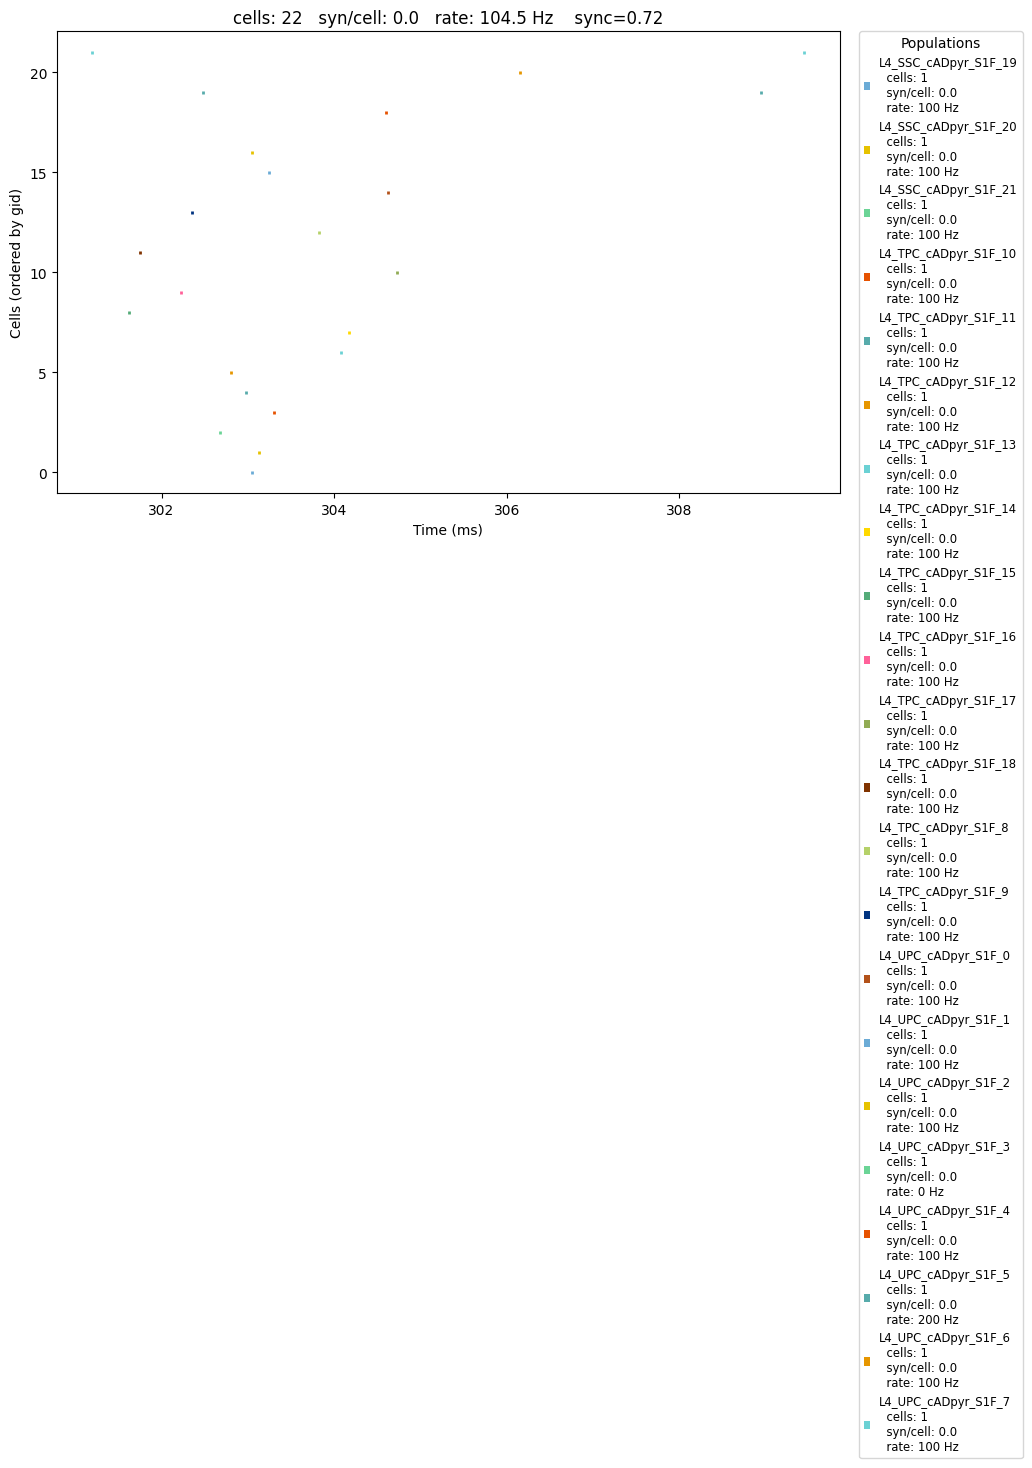

In [44]:
sim.analysis.plotRaster(timeRange=[300,310], figSize=(18,6), 
    popRates=True);

Preparing spike data...
Plotting raster...


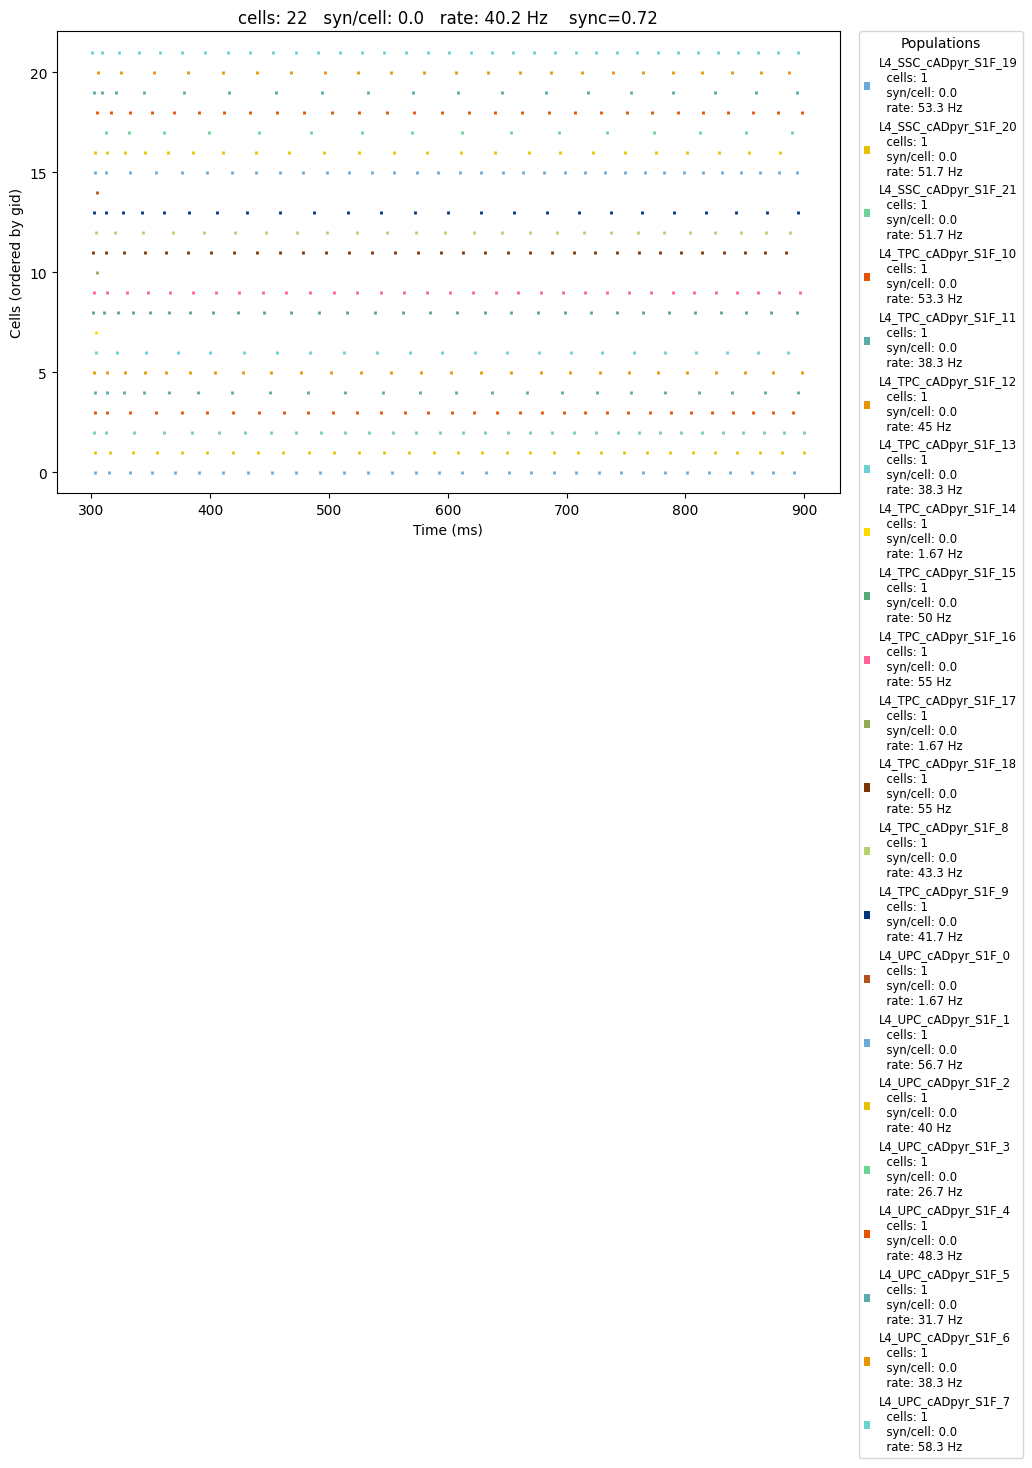

In [45]:
sim.analysis.plotRaster(timeRange=[300,900], figSize=(18,6),
    popRates=True);

Plotting recorded cell traces ... trace


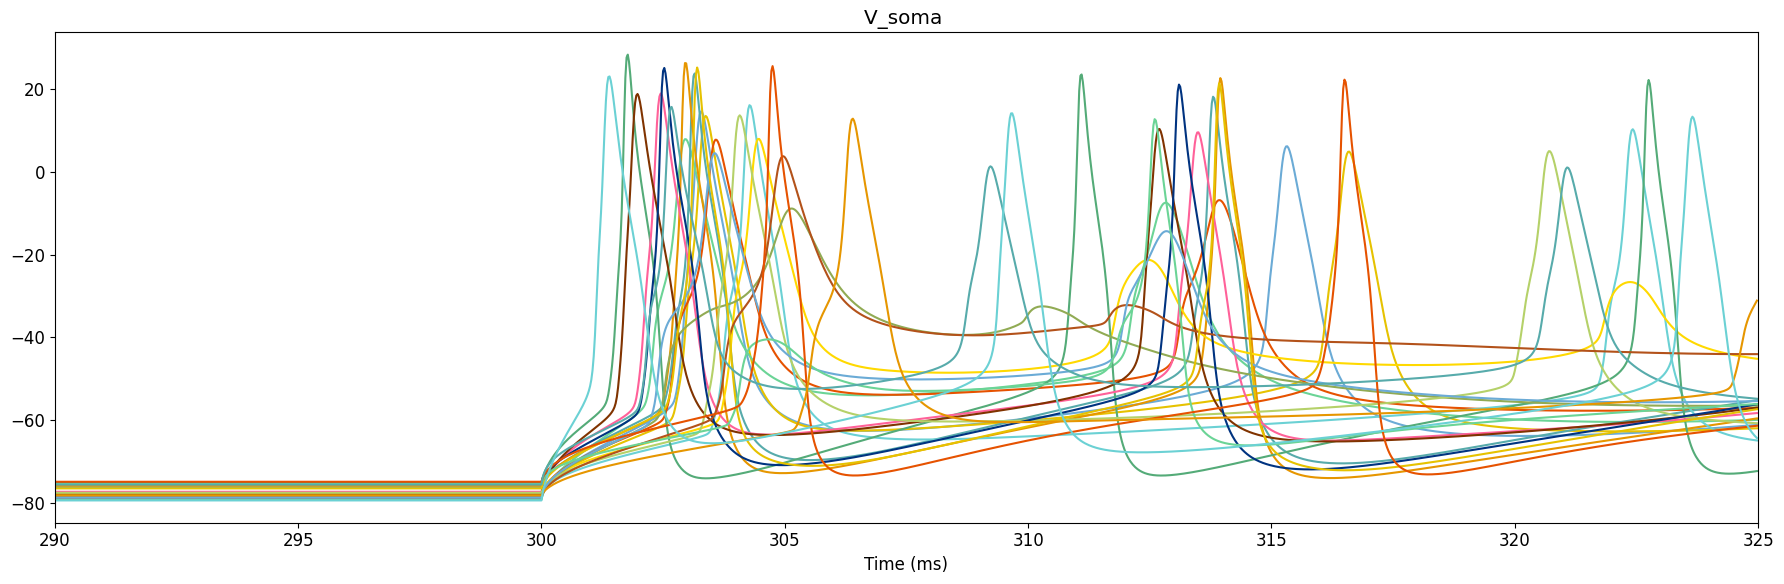

In [46]:
sim.analysis.plotTraces(timeRange=[290,325], overlay=True, oneFigPer='trace', figSize=(18,6));
# sim.analysis.plotTraces(timeRange=[290,320], overlay=False, oneFigPer='trace', figSize=(18,36));

Plotting recorded cell traces ... cell


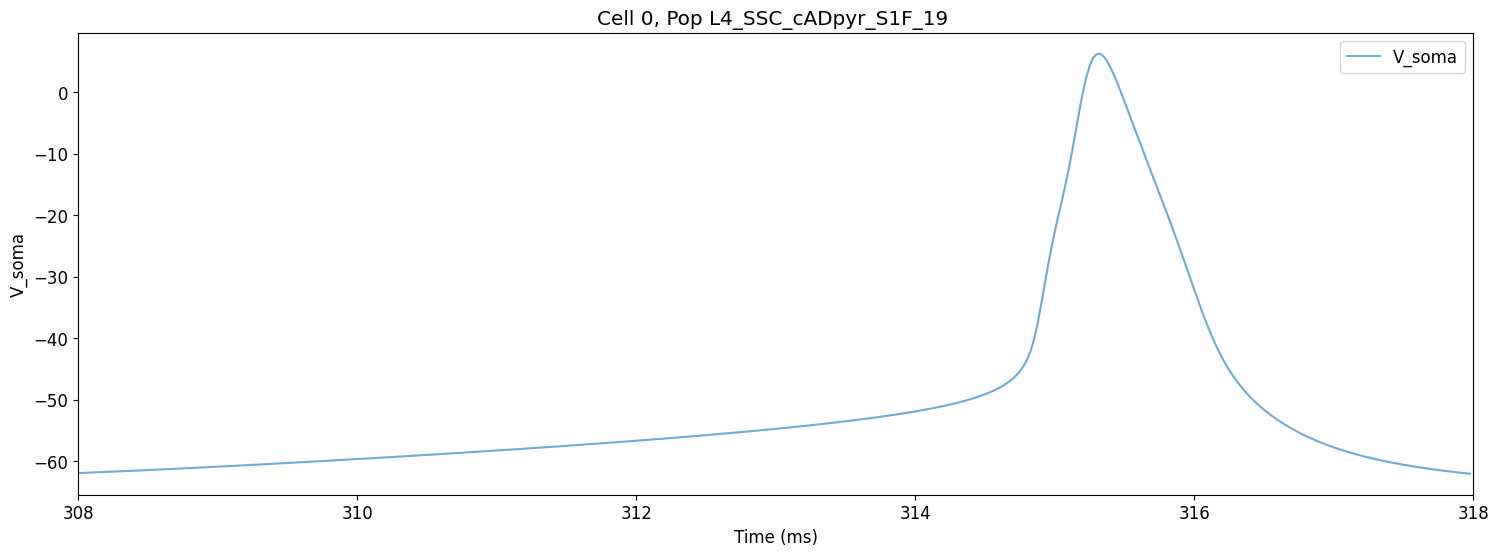

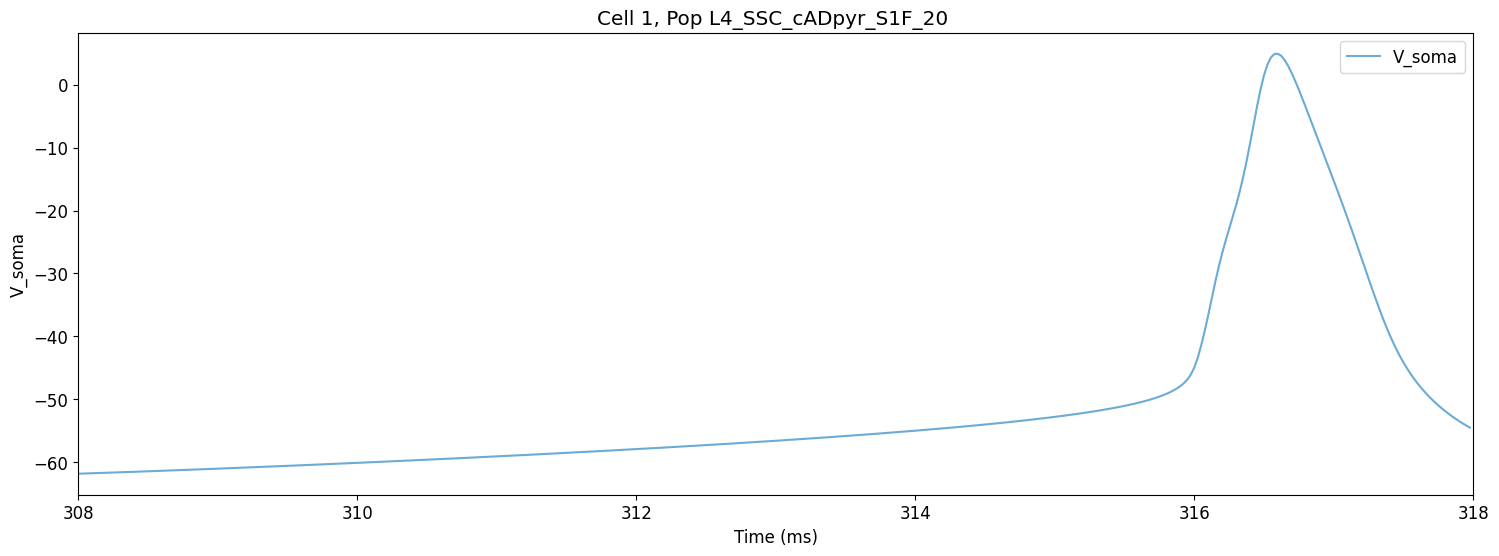

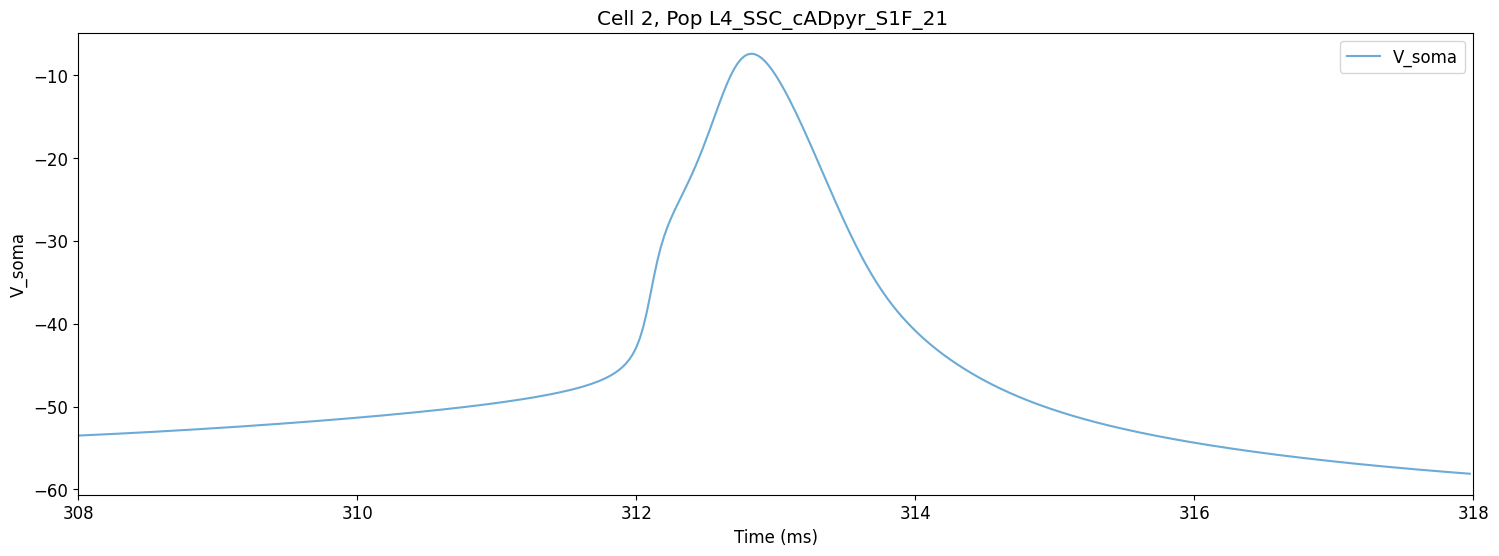

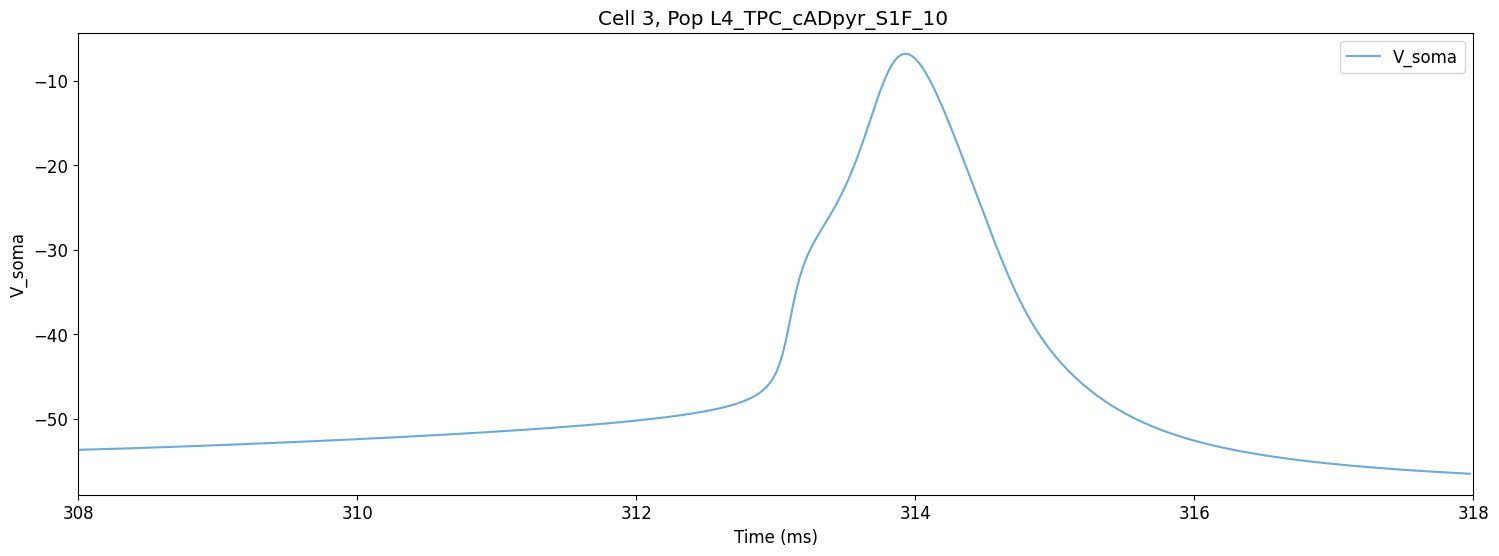

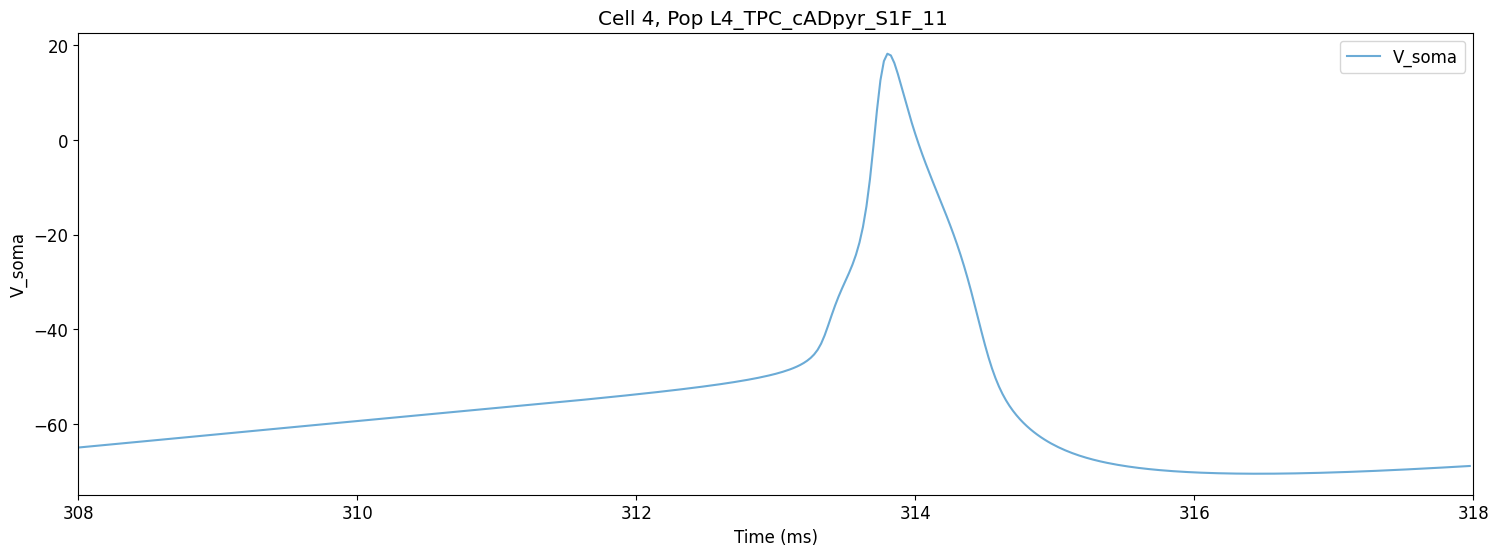

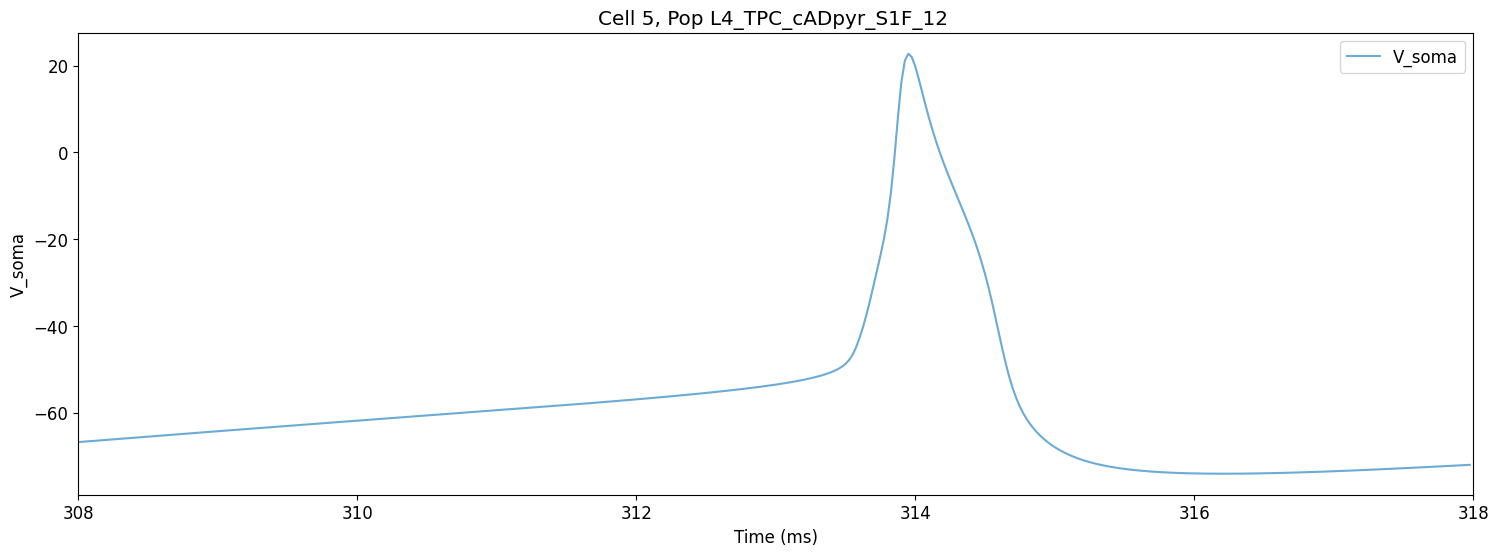

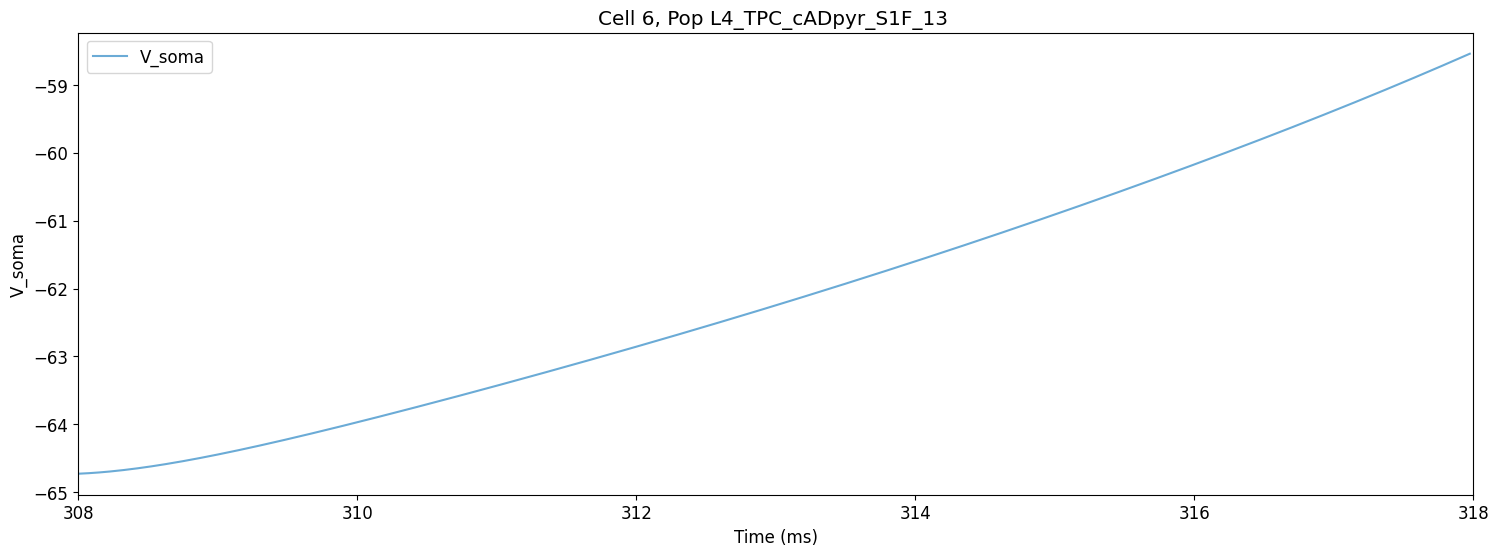

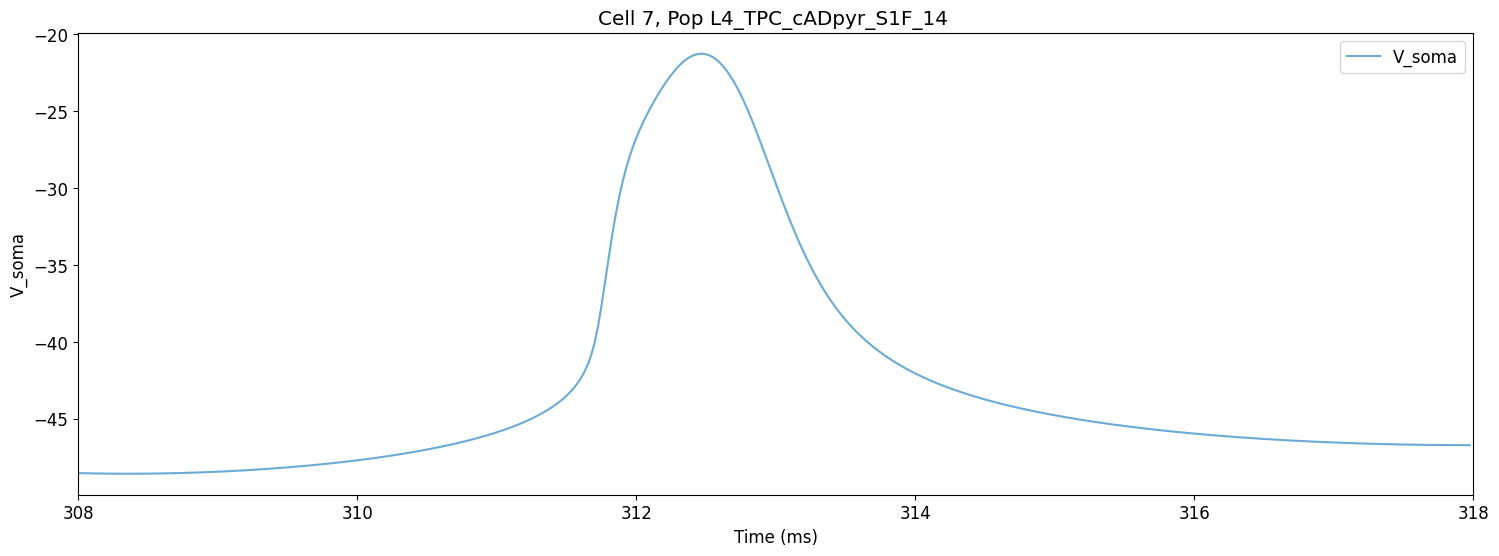

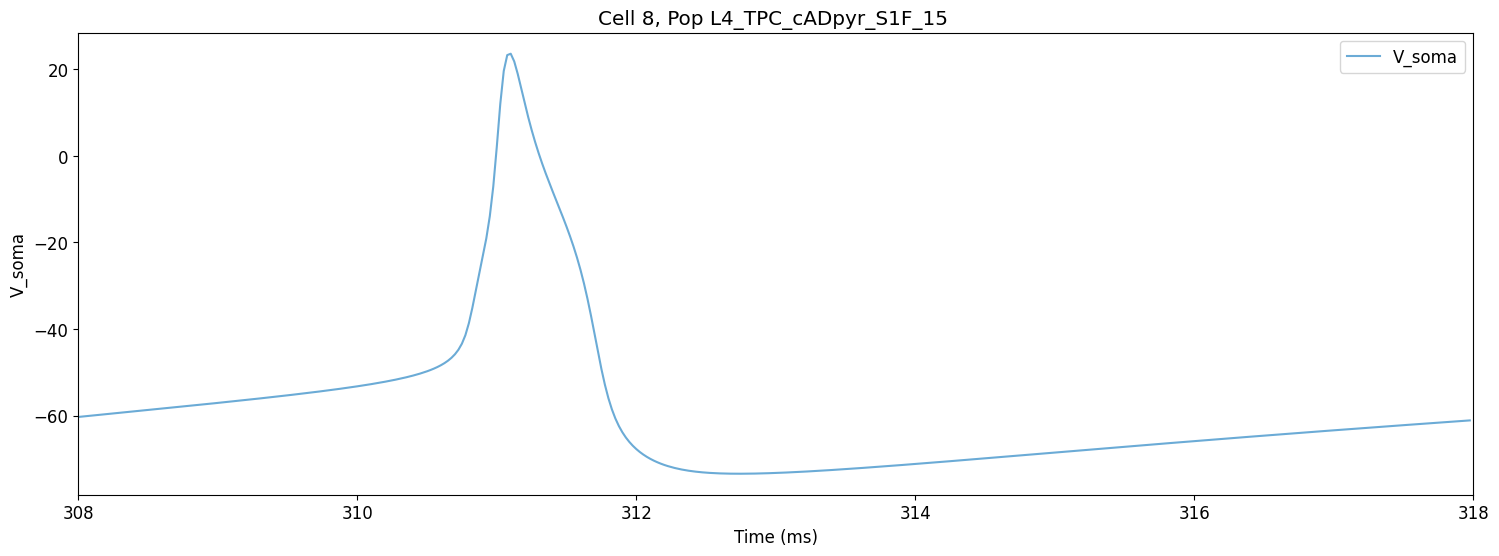

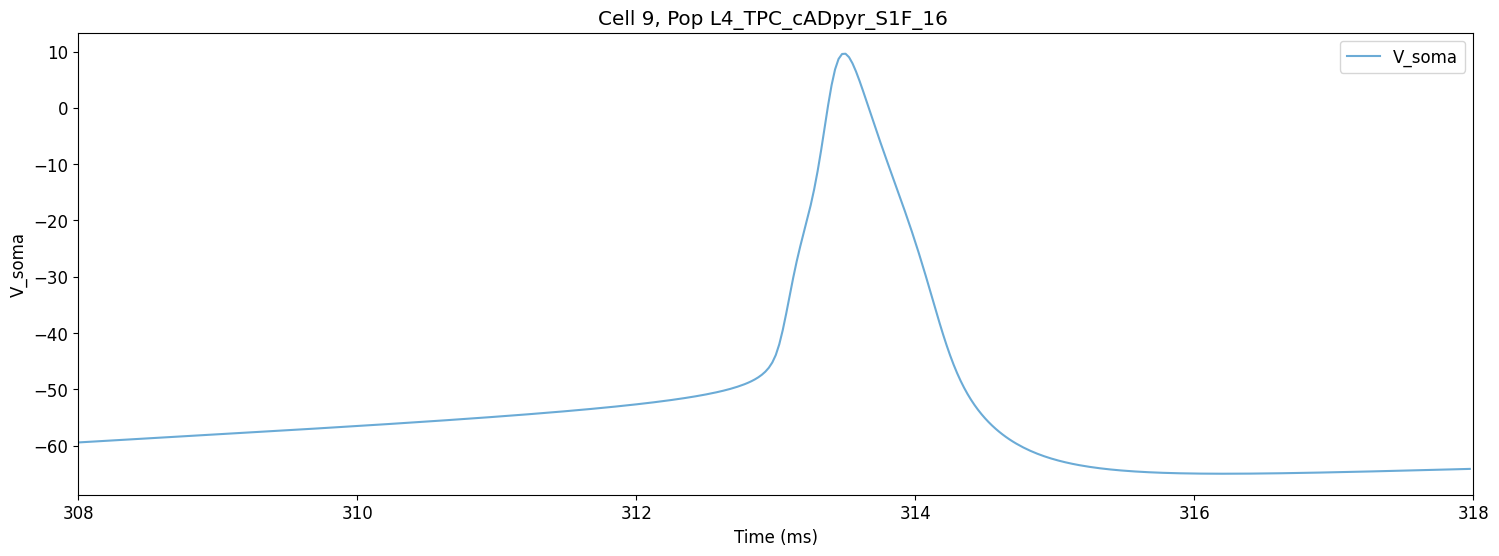

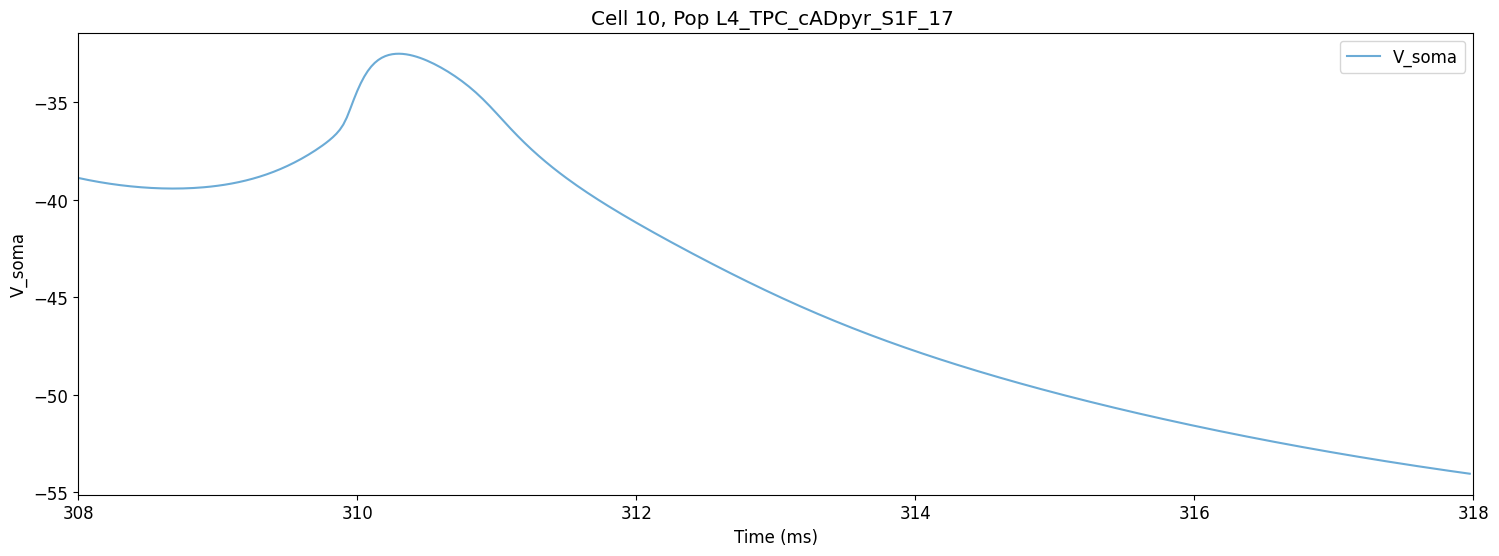

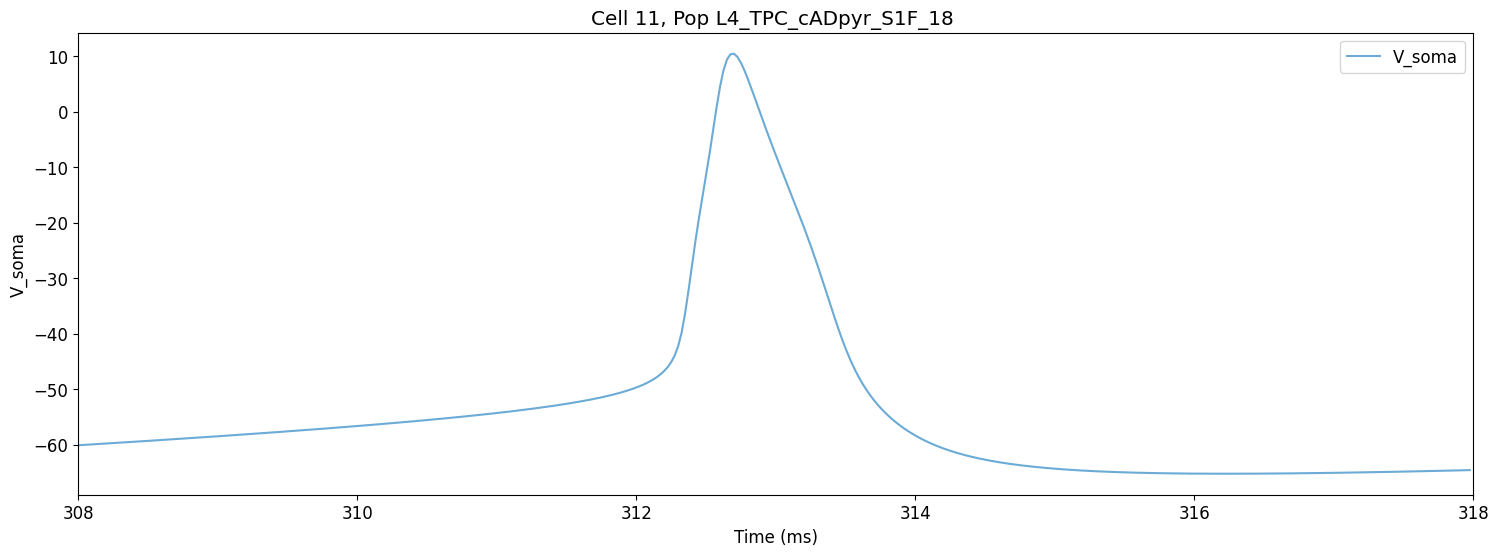

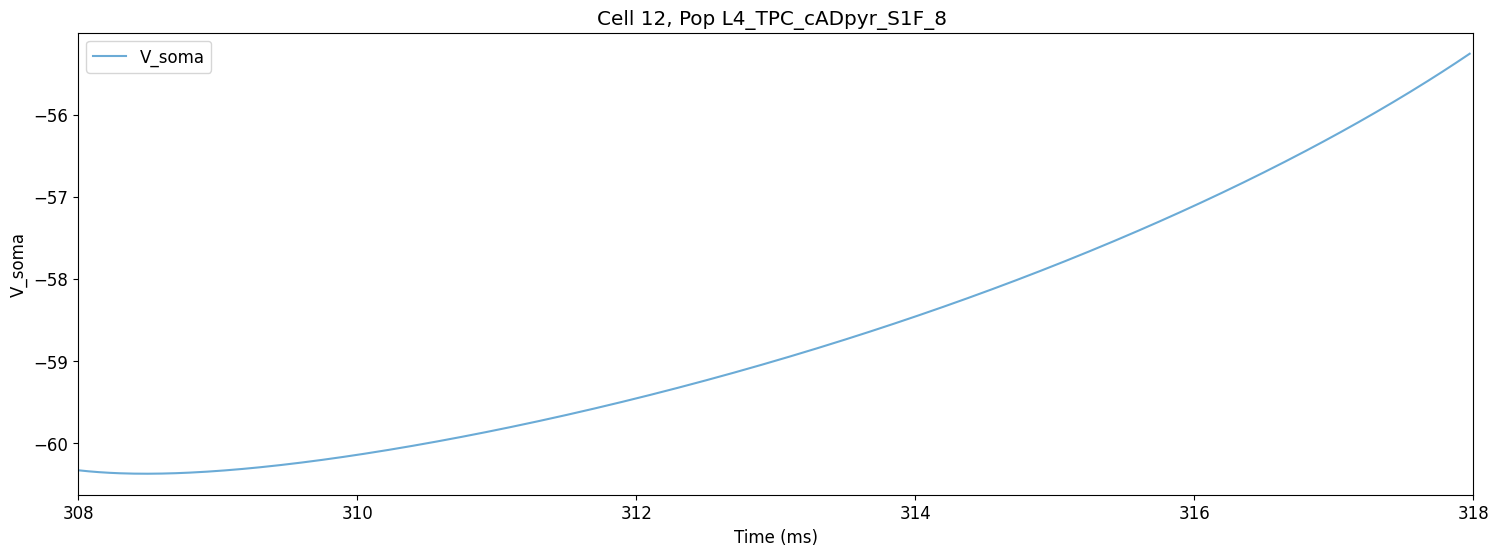

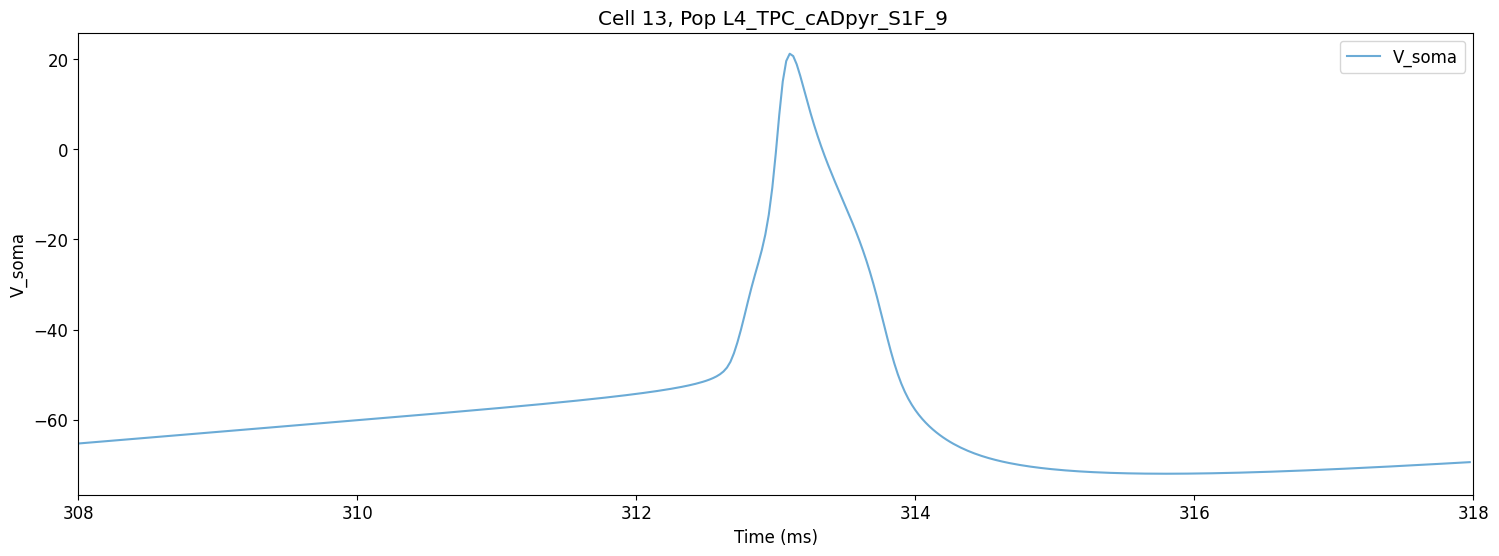

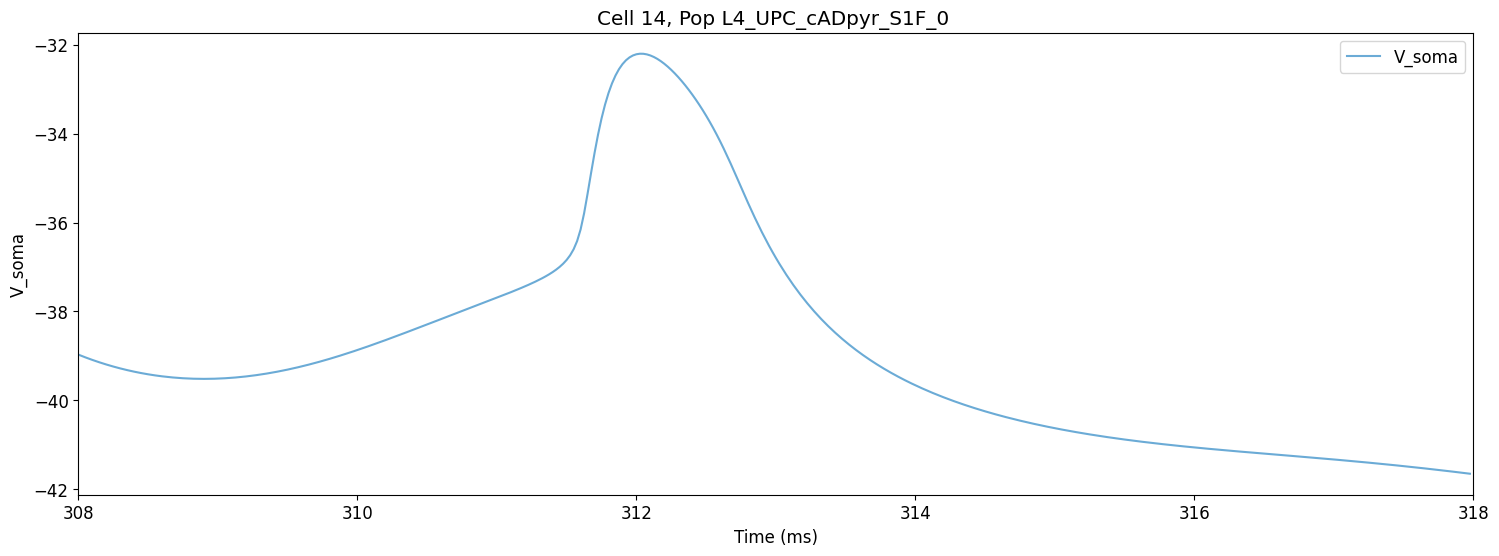

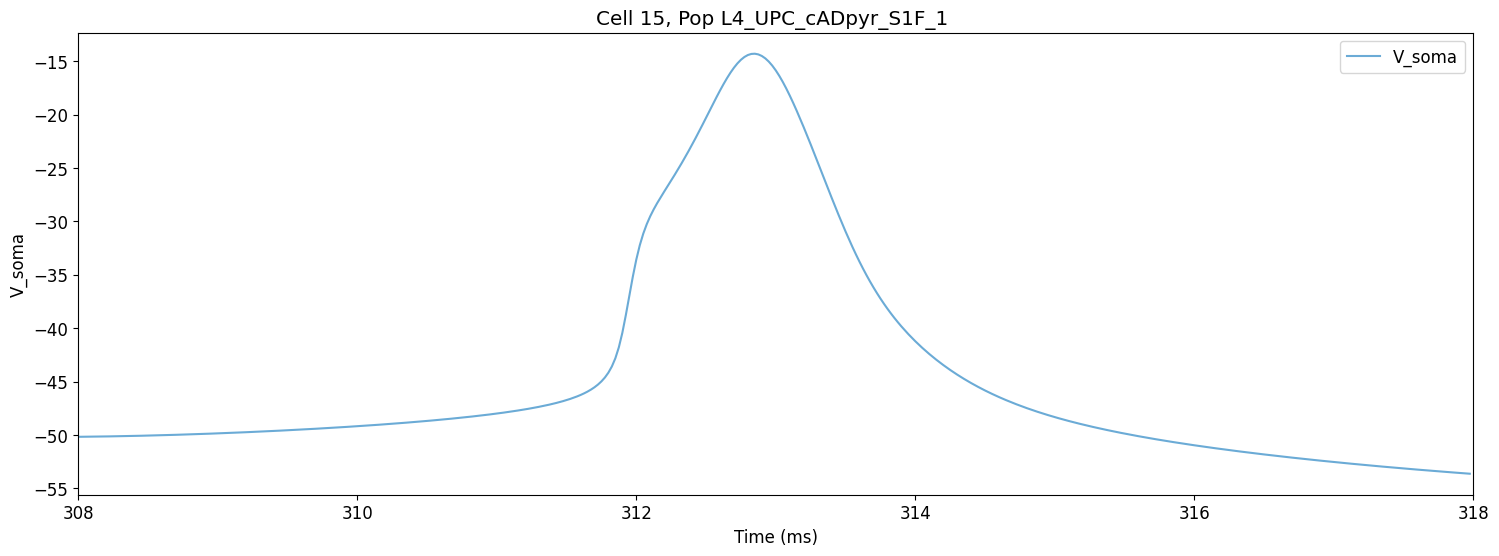

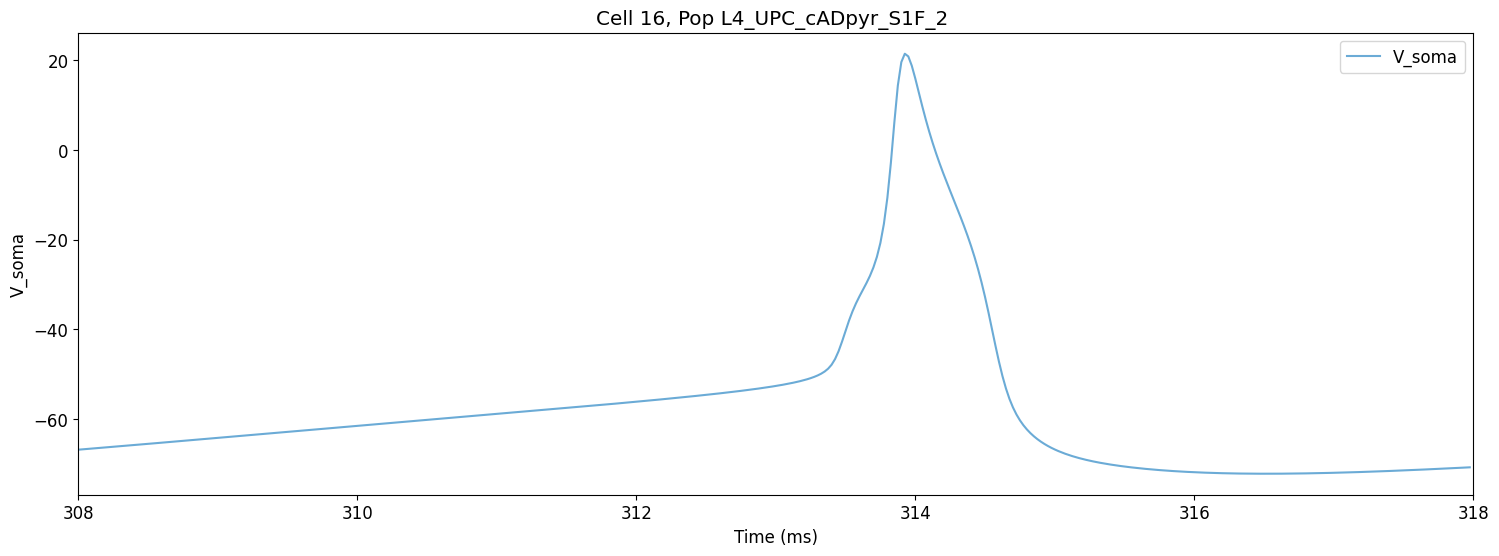

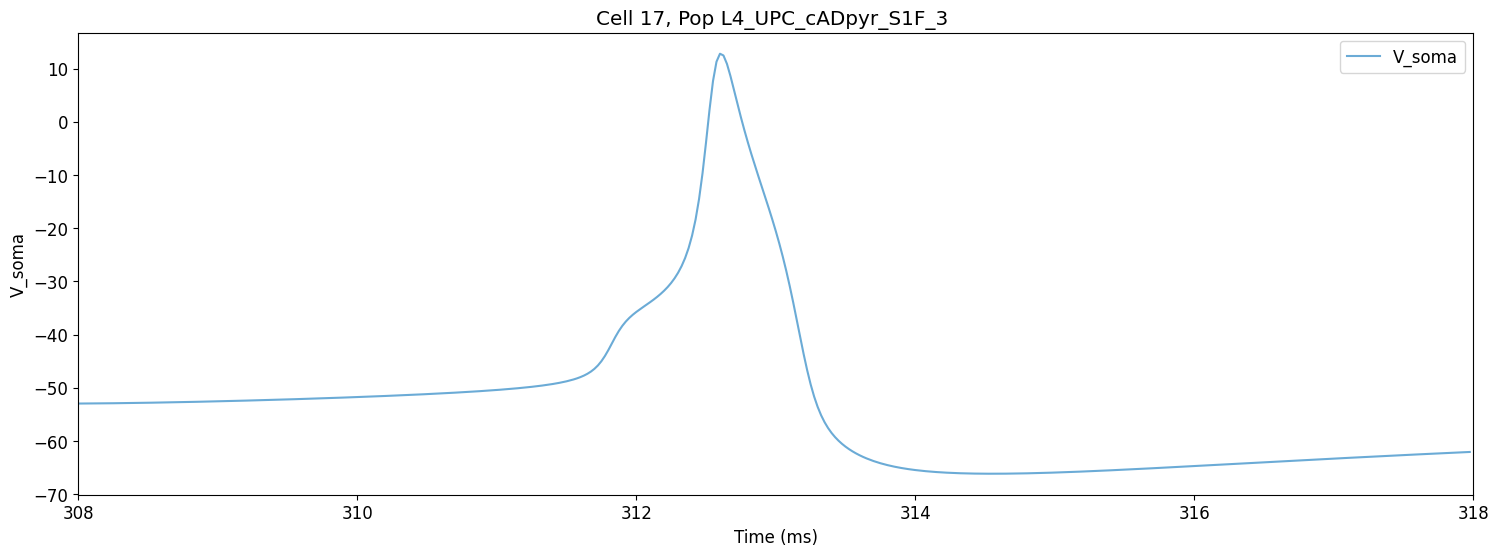

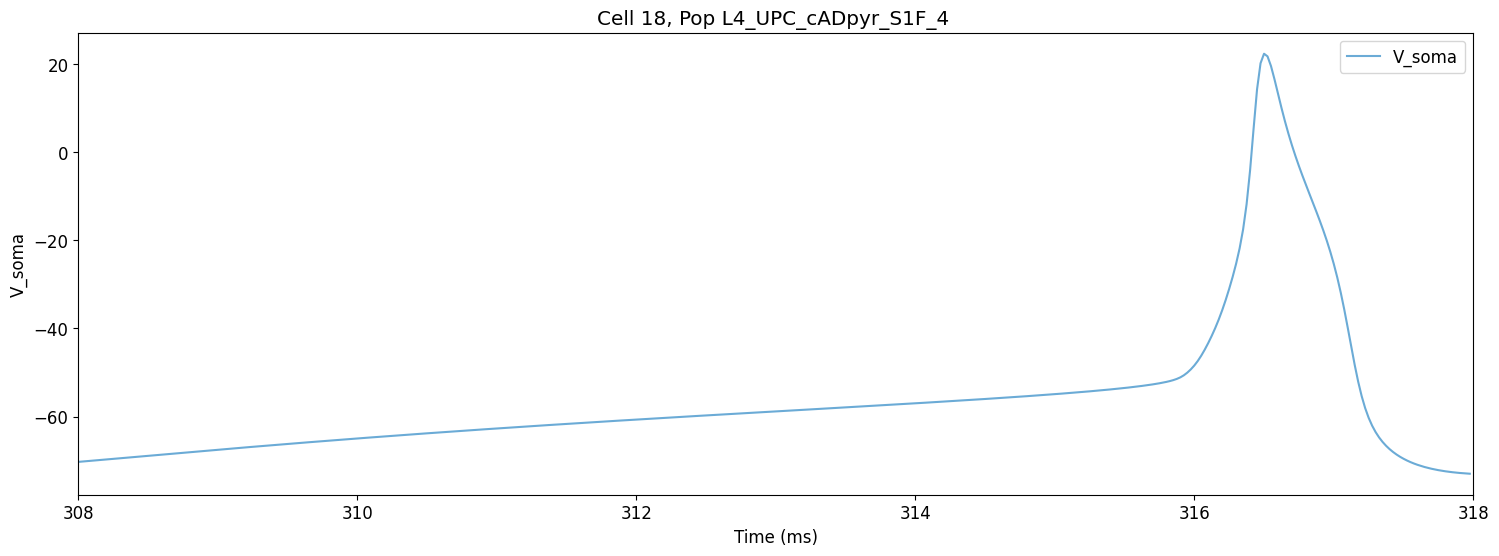

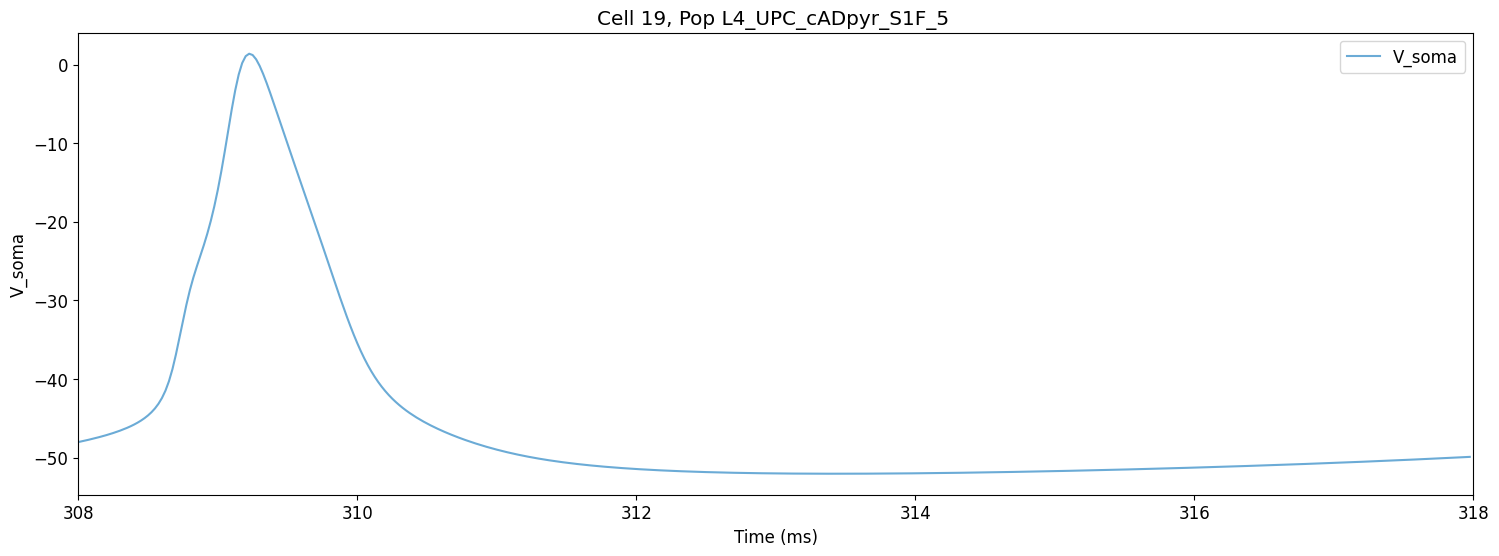

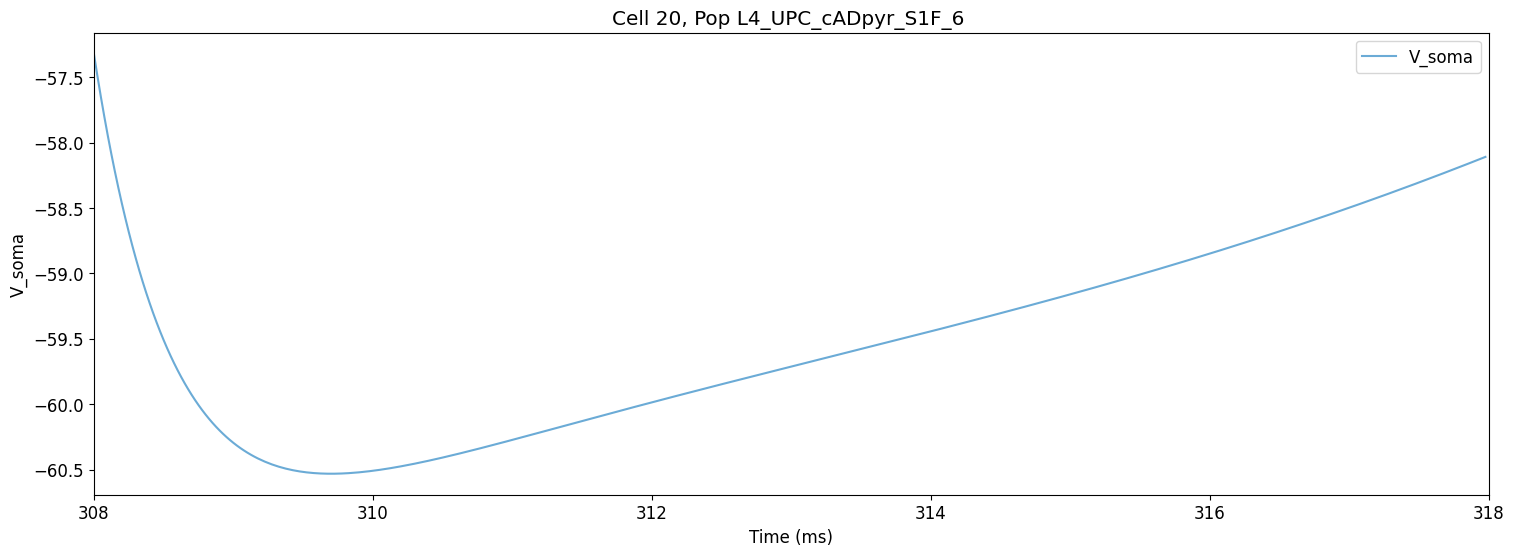

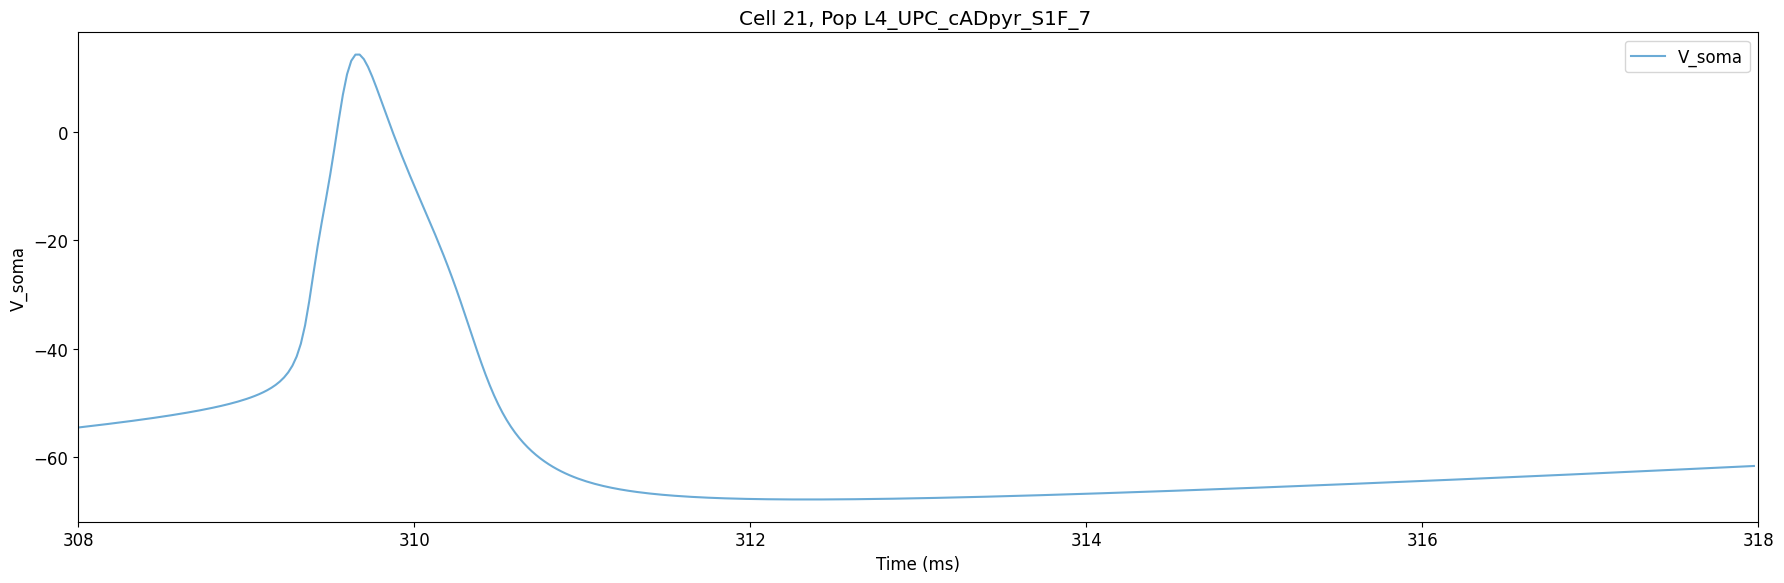

In [47]:
sim.analysis.plotTraces(timeRange=[308,318], overlay=True, oneFigPer='cell', figSize=(18,6));

Plotting recorded cell traces ... trace


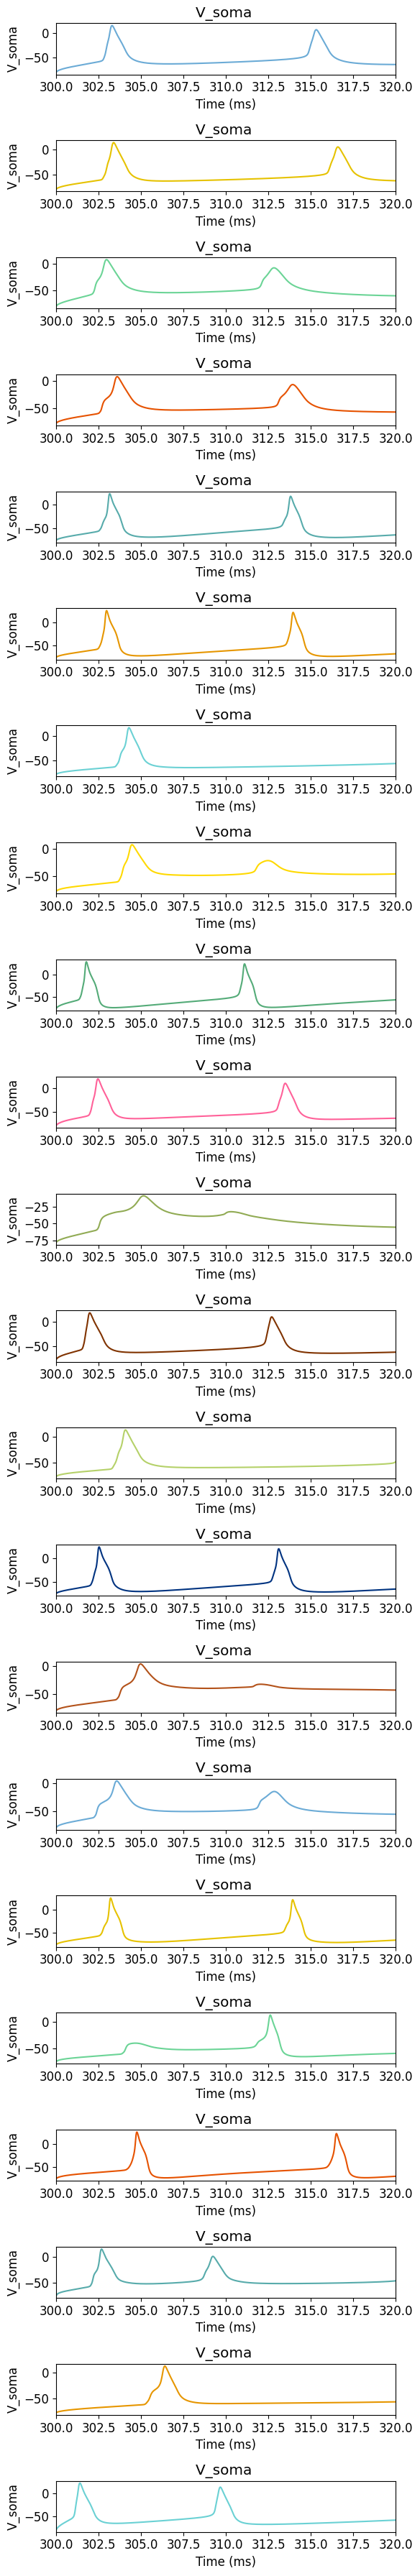

In [48]:
sim.analysis.plotTraces(timeRange=[300,320], overlay=False, oneFigPer='trace', figSize=(6,36));
# sim.analysis.plotTraces(timeRange=[250,1000], overlay=False, oneFigPer='trace', figSize=(18,36));

Plotting 2D representation of network cell locations and connections...


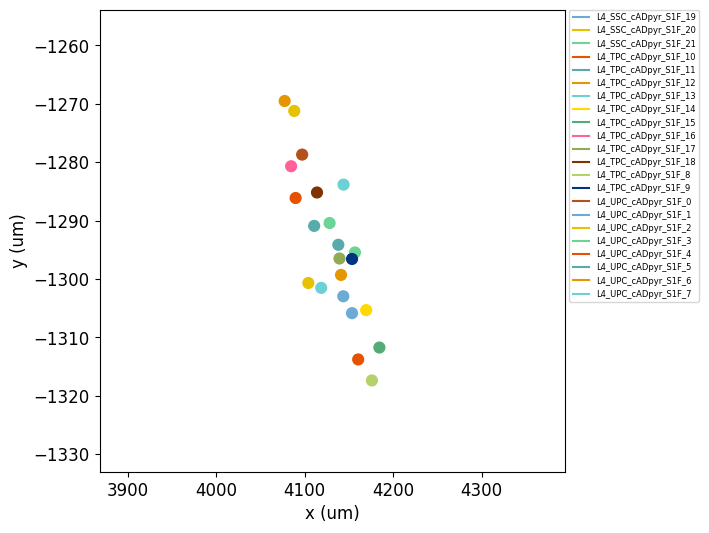

Plotting 2D representation of network cell locations and connections...


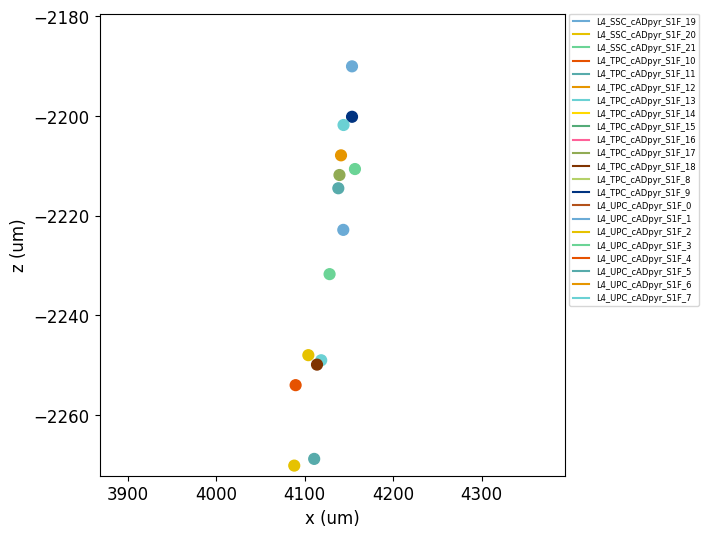

In [49]:
sim.analysis.plot2Dnet(showConns=True, figSize=(6, 6),fontSize=6);
sim.analysis.plot2Dnet(showConns=True, figSize=(6, 6),fontSize=6, view = 'xz');

Plotting 3D cell shape ...


(<Figure size 2600x2600 with 2 Axes>, {})

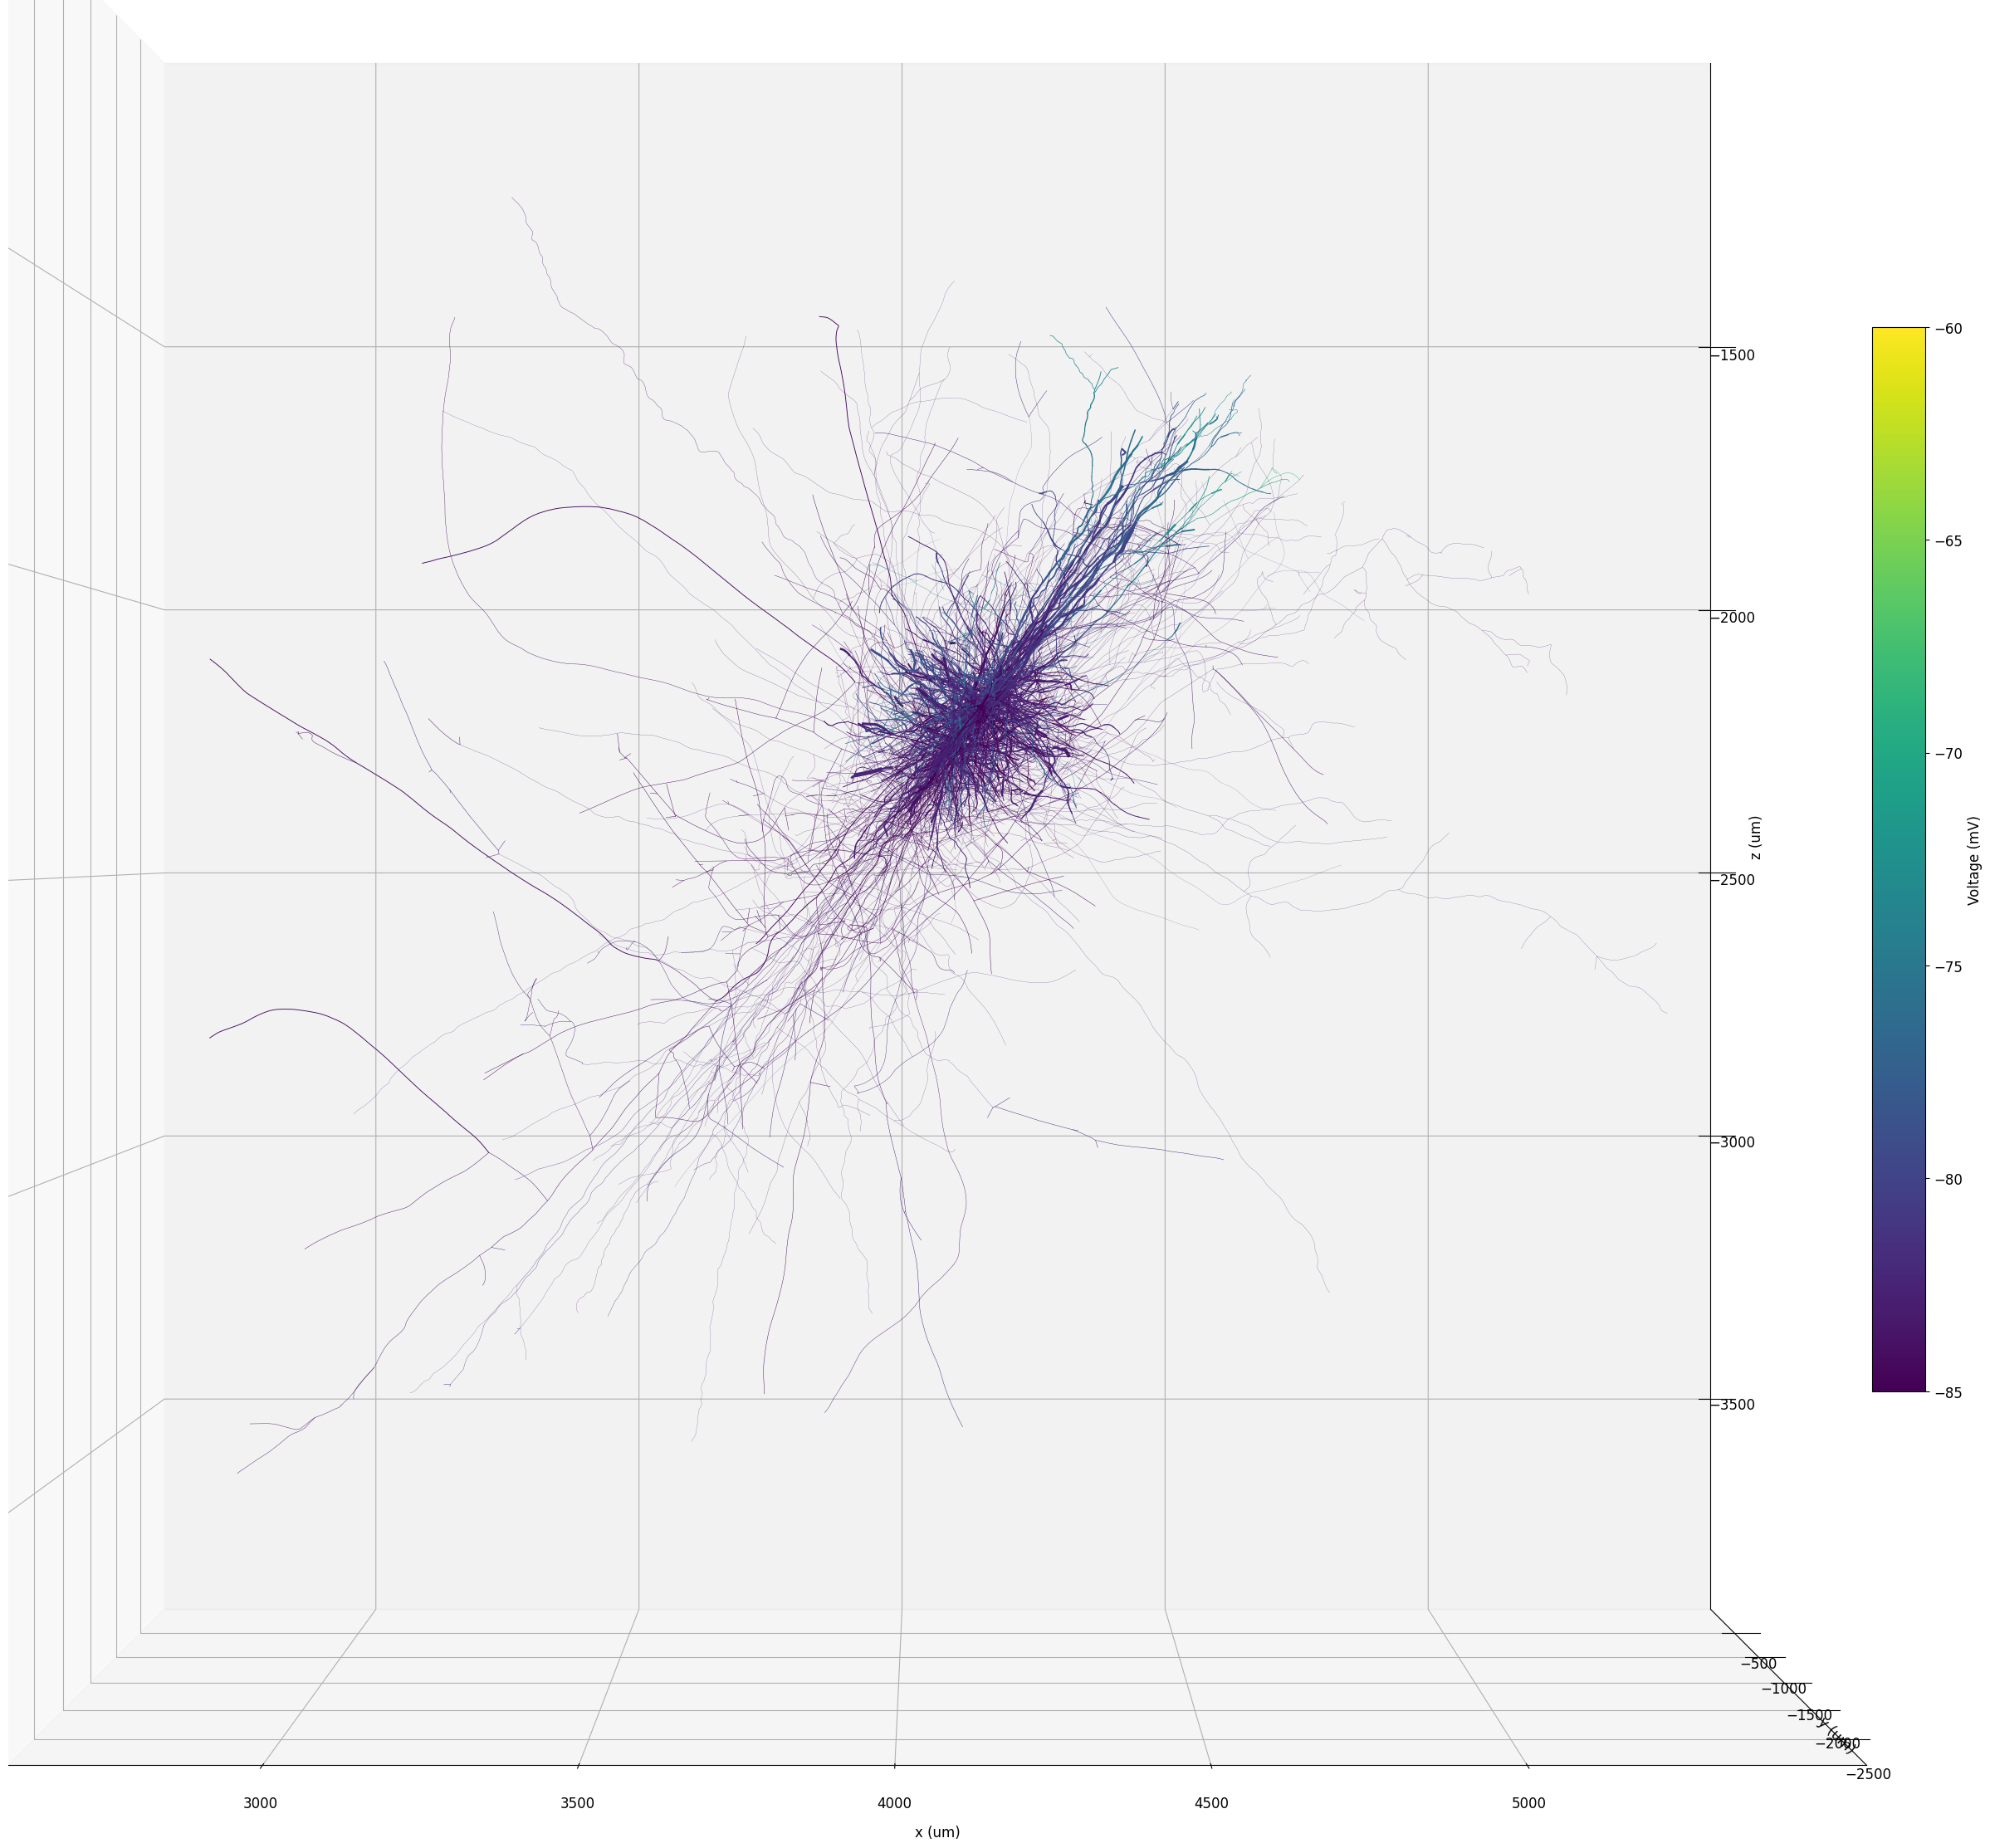

In [50]:
sim.analysis.plotShape(includePre= [ii for ii in range(len(node_gid))], includePost= [ii for ii in range(len(node_gid))], 
                       includeAxon=True, showSyns=True, showElectrodes=False,
    cvar= 'voltage', dist=0.6, elev=0, azim=-90, 
    axisLabels=True, synStyle='o', 
    clim= [-85.0, -60.0], showFig=False, synSize=3, saveFig=False, figSize=(26,26))

Plotting 3D cell shape ...


(<Figure size 3600x3600 with 2 Axes>, {})

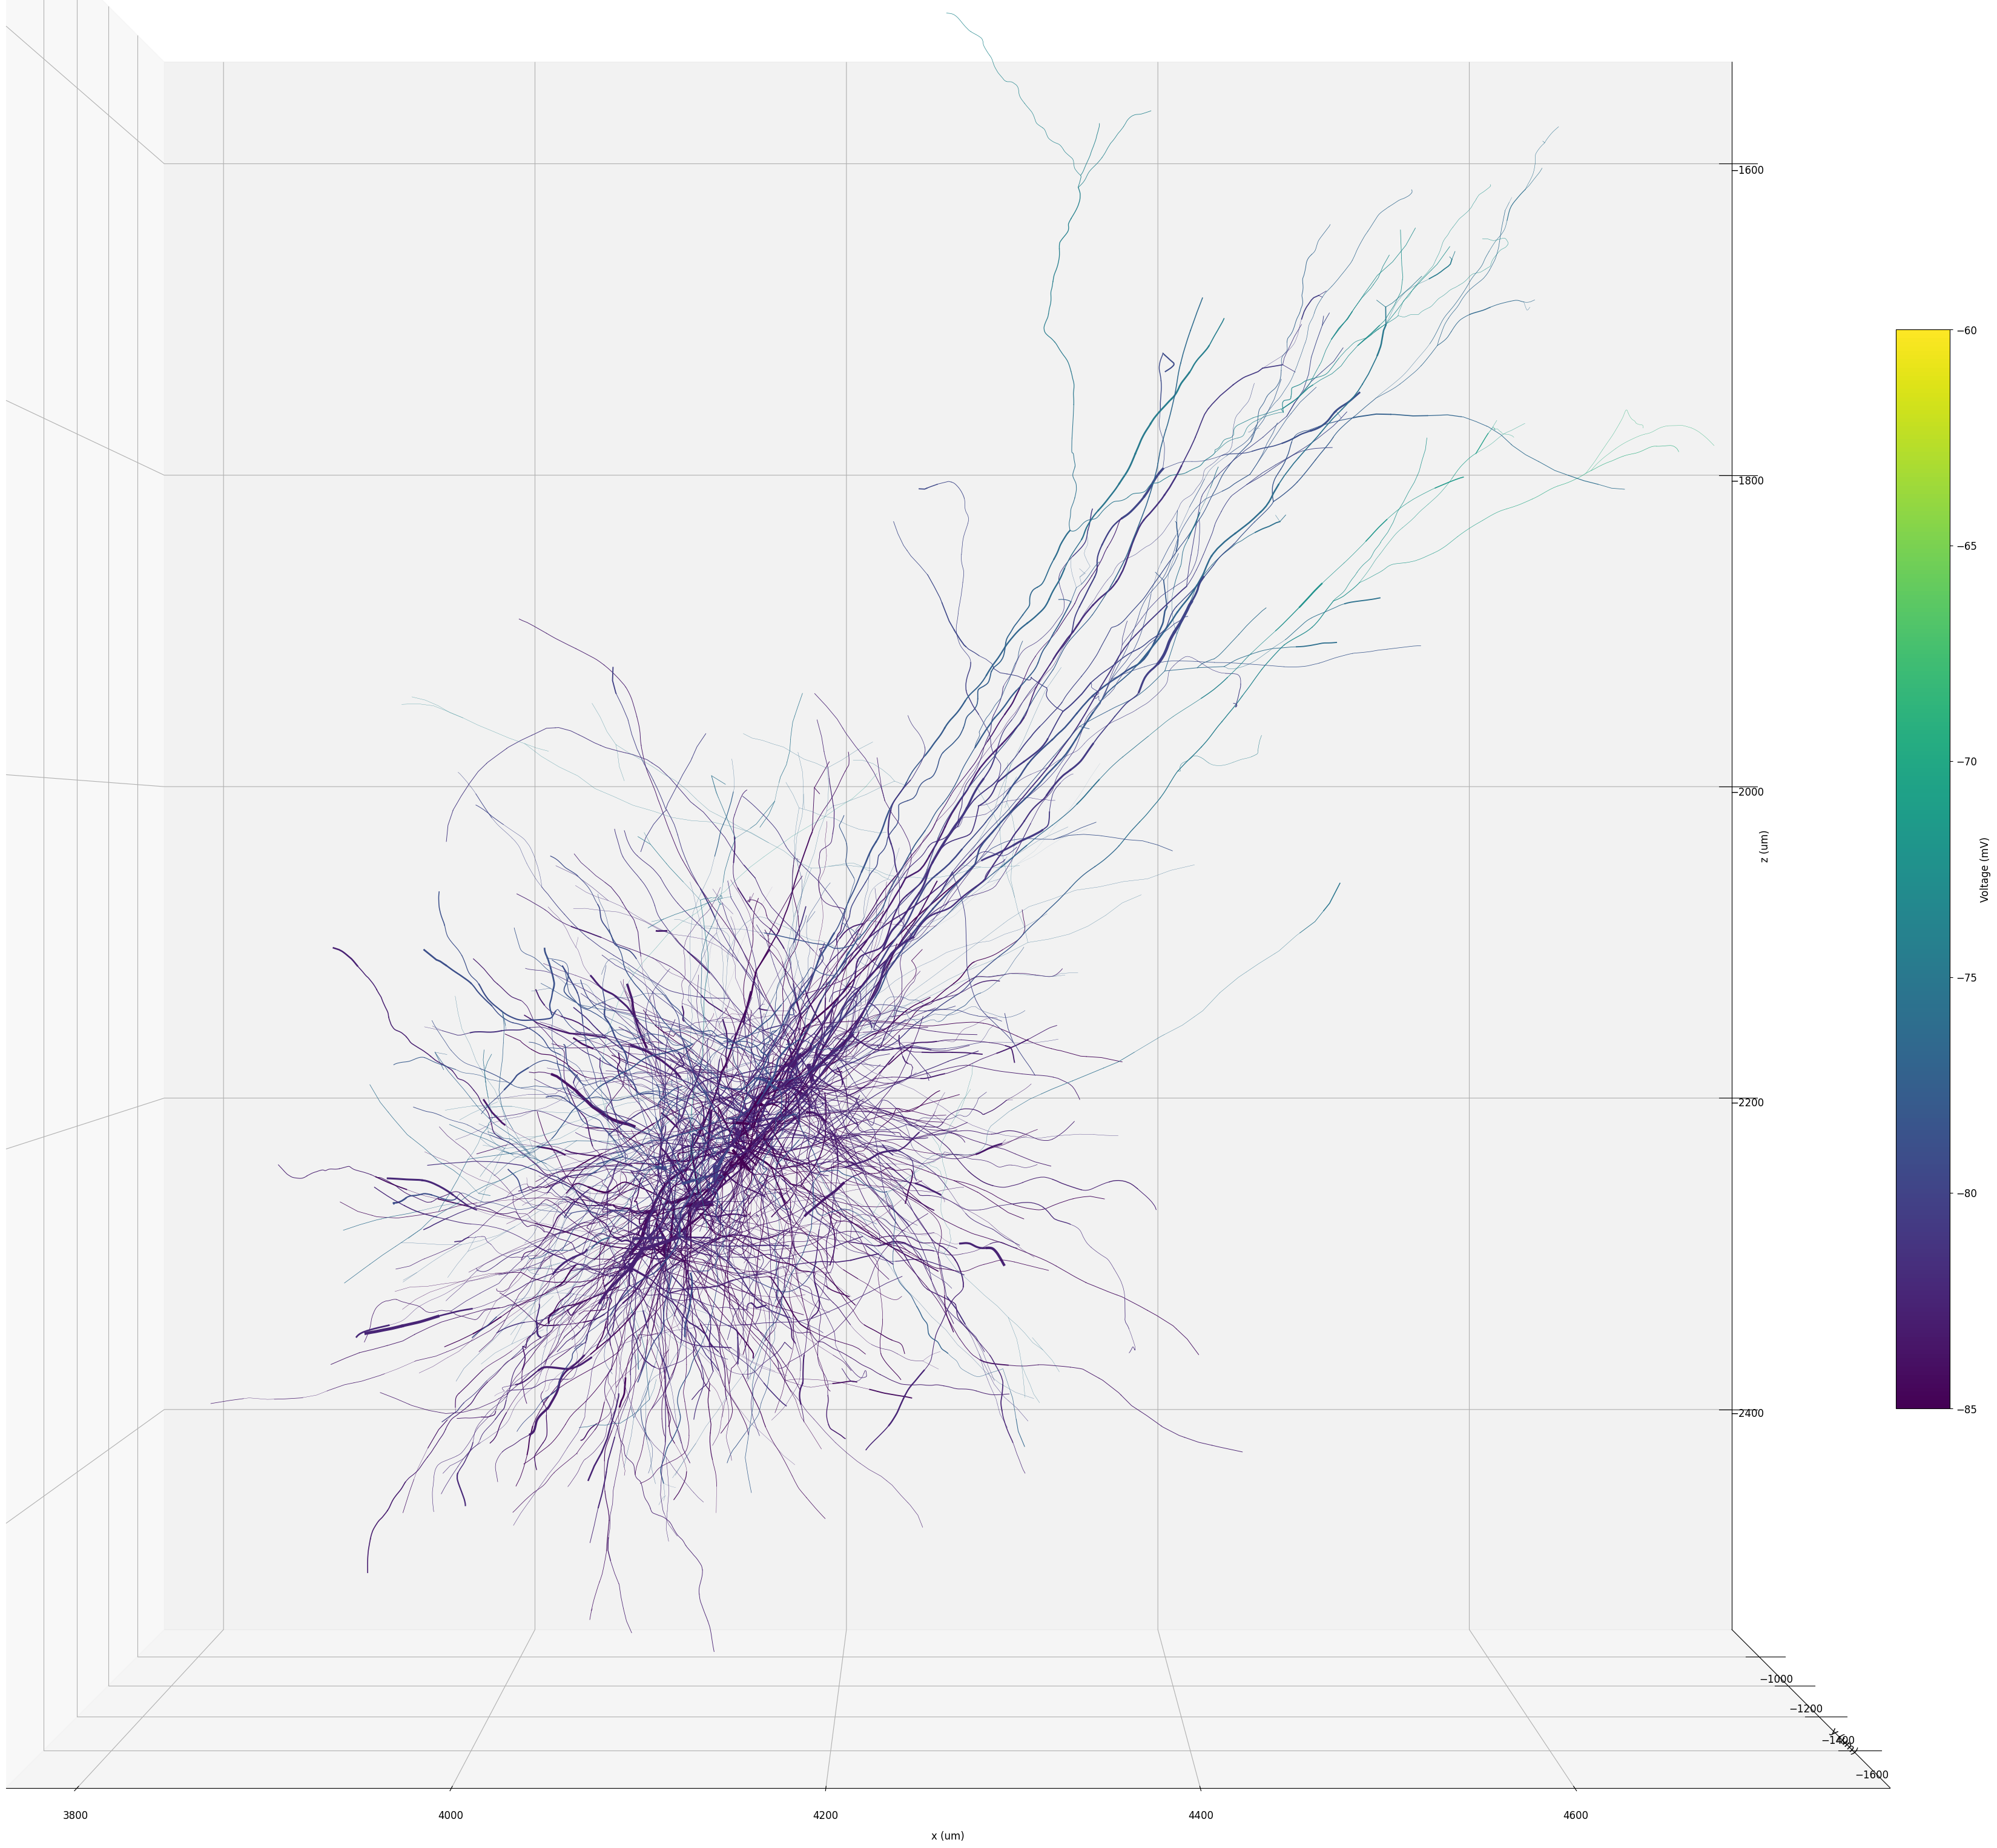

In [51]:
sim.analysis.plotShape(includePre= [ii for ii in range(len(node_gid))], includePost= [ii for ii in range(len(node_gid))], 
                       includeAxon=False, showSyns=False, showElectrodes=False,
    cvar= 'voltage', dist=0.6, elev=0, azim=-90, 
    axisLabels=True, synStyle='o', 
    clim= [-85.0, -60.0], showFig=False, synSize=2, saveFig=False, figSize=(36,36))

Plotting 3D cell shape ...


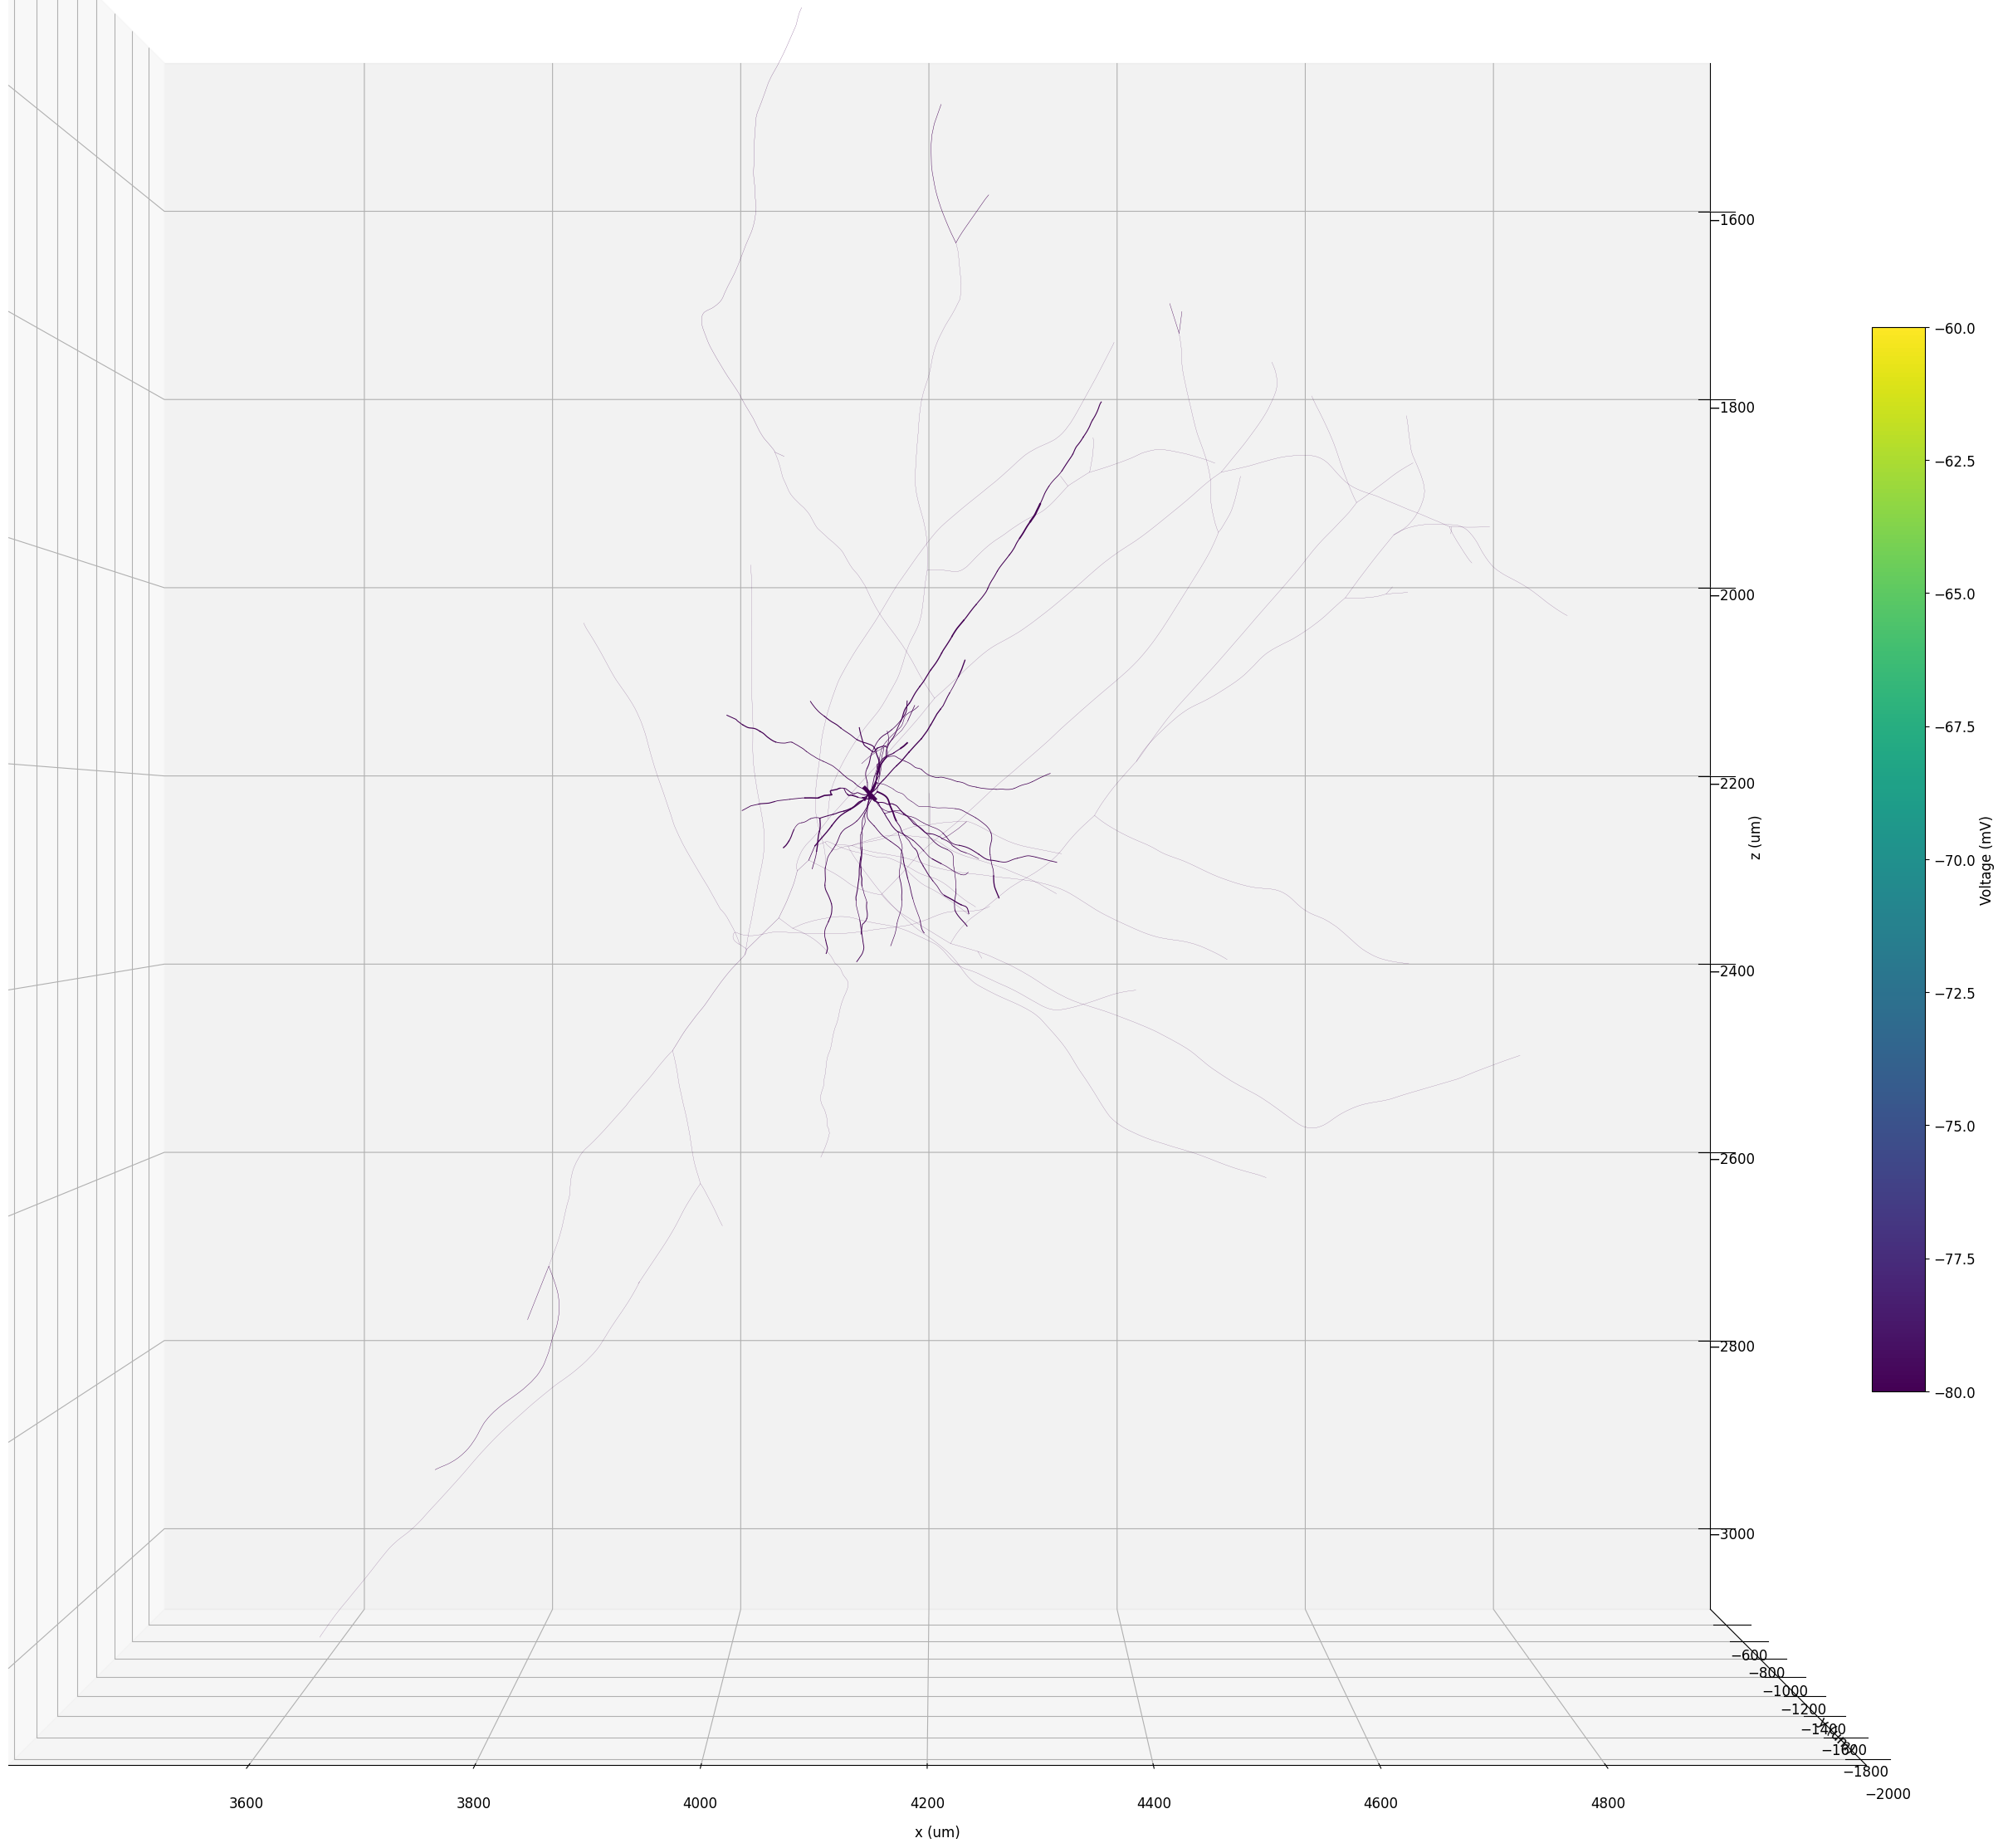

In [52]:
for ii in range(15,16):
        sim.analysis.plotShape(includePre= [ii], includePost= [ii], 
        includeAxon=True, showSyns=True, showElectrodes=False,
        cvar= 'voltage', dist=0.6, elev=0, azim=-90, 
        axisLabels=True, synStyle='o', 
        clim= [-80, -60], showFig=False, synSize=2, saveFig=True, figSize=(26,26))

In [53]:
for gid in sorted(cellName_list.keys()):
    for gid2 in sorted(cellName_list.keys()):

        var_list_a = ['@source_node', 'afferent_center_x', 'afferent_center_y', 'afferent_center_z', 'afferent_section_id', 'afferent_section_pos', 'afferent_section_type', 'afferent_segment_id', 
                    'afferent_segment_offset', 'afferent_surface_x', 'afferent_surface_y', 'afferent_surface_z', '@target_node', 'efferent_center_x', 'efferent_center_y', 'efferent_center_z', 
                    'efferent_section_id', 'efferent_section_pos', 'efferent_section_type', 'efferent_segment_id', 'efferent_segment_offset', 'efferent_surface_x', 'efferent_surface_y', 
                    'efferent_surface_z', 'spine_length', 'syn_property_rule', 'syn_type_id']
        # afferent edges of node_ids[gid2]
        sampled_edge_ids = conn.afferent_edges(gid2)    
        # var_list_a = sorted(conn.property_names)[0:12]    
        var_list_a =  ['@source_node', 'afferent_center_x', 'afferent_center_y', 'afferent_center_z', 
                    'afferent_section_pos', 'afferent_section_type', 'afferent_segment_id',
                    'afferent_section_id', 
                    'afferent_segment_offset',
                    # '@target_node', 'efferent_center_x', 'efferent_center_y', 'efferent_center_z', 
                    #   'efferent_section_id',     
                    #   'efferent_segment_offset', 
                    #   'spine_length', 'syn_property_rule', 'syn_type_id'
                    ]
        connsinfo = conn.get(sampled_edge_ids,var_list_a)

        if len(connsinfo.get(connsinfo['@source_node']==gid)) >= 1:
            print(gid,cellName_list[gid], cellName_list[gid2],gid2,len(connsinfo.get(connsinfo['@source_node']==gid)))
            # print(netParams.connParams[cellName_list[gid]+'->'+cellName_list[gid2]])

109126 L4_UPC_cADpyr_S1F_0 L4_UPC_cADpyr_S1F_4 114352 5
109632 L4_UPC_cADpyr_S1F_1 L4_UPC_cADpyr_S1F_4 114352 4
109632 L4_UPC_cADpyr_S1F_1 L4_UPC_cADpyr_S1F_6 116011 5
109632 L4_UPC_cADpyr_S1F_1 L4_SSC_cADpyr_S1F_20 141213 5
112531 L4_UPC_cADpyr_S1F_2 L4_UPC_cADpyr_S1F_4 114352 9
117199 L4_UPC_cADpyr_S1F_7 L4_UPC_cADpyr_S1F_5 115007 3
117199 L4_UPC_cADpyr_S1F_7 L4_TPC_cADpyr_S1F_13 132504 20
117199 L4_UPC_cADpyr_S1F_7 L4_SSC_cADpyr_S1F_21 141369 3
118008 L4_TPC_cADpyr_S1F_8 L4_TPC_cADpyr_S1F_12 131862 3
118551 L4_TPC_cADpyr_S1F_9 L4_UPC_cADpyr_S1F_7 117199 3
118903 L4_TPC_cADpyr_S1F_10 L4_UPC_cADpyr_S1F_5 115007 4
131862 L4_TPC_cADpyr_S1F_12 L4_UPC_cADpyr_S1F_4 114352 14
131862 L4_TPC_cADpyr_S1F_12 L4_TPC_cADpyr_S1F_18 137858 3
131862 L4_TPC_cADpyr_S1F_12 L4_SSC_cADpyr_S1F_20 141213 6
133289 L4_TPC_cADpyr_S1F_14 L4_UPC_cADpyr_S1F_1 109632 9
133289 L4_TPC_cADpyr_S1F_14 L4_UPC_cADpyr_S1F_4 114352 17
133289 L4_TPC_cADpyr_S1F_14 L4_UPC_cADpyr_S1F_6 116011 17
133289 L4_TPC_cADpyr_S1F_14 L4_

In [54]:
gid = 138402
gid2 = 142232

var_list_a = ['@source_node', 'afferent_center_x', 'afferent_center_y', 'afferent_center_z', 'afferent_section_id', 'afferent_section_pos', 'afferent_section_type', 'afferent_segment_id', 
              'afferent_segment_offset', 'afferent_surface_x', 'afferent_surface_y', 'afferent_surface_z', '@target_node', 'efferent_center_x', 'efferent_center_y', 'efferent_center_z', 
              'efferent_section_id', 'efferent_section_pos', 'efferent_section_type', 'efferent_segment_id', 'efferent_segment_offset', 'efferent_surface_x', 'efferent_surface_y', 
              'efferent_surface_z', 'spine_length', 'syn_property_rule', 'syn_type_id']
# afferent edges of node_ids[gid2]
sampled_edge_ids = conn.afferent_edges(gid2)    
# var_list_a = sorted(conn.property_names)[0:12]    
var_list_a =  ['@source_node', 'afferent_center_x', 'afferent_center_y', 'afferent_center_z', 
               'afferent_section_pos', 'afferent_section_type', 'afferent_segment_id',
               'afferent_section_id', 
              'afferent_segment_offset',
              # '@target_node', 'efferent_center_x', 'efferent_center_y', 'efferent_center_z', 
            #   'efferent_section_id',     
            #   'efferent_segment_offset', 
            #   'spine_length', 'syn_property_rule', 'syn_type_id'
              ]
connsinfo = conn.get(sampled_edge_ids,var_list_a)
connsinfo.get(connsinfo['@source_node']==gid)

,@source_node,afferent_center_x,afferent_center_y,afferent_center_z,afferent_section_pos,afferent_section_type,afferent_segment_id,afferent_section_id,afferent_segment_offset
227477635,138402,4097.658203,-1278.120239,-2268.350098,0.0,1,0,0,0.0
227477636,138402,4097.658203,-1278.120239,-2268.350098,0.0,1,0,0,0.0
227477637,138402,4097.658203,-1278.120239,-2268.350098,0.0,1,0,0,0.0
227477638,138402,4097.658203,-1278.120239,-2268.350098,0.0,1,0,0,0.0


In [55]:
# print(np.array(preA) + np.array([3000.0, -2000.0, -3500.0]), np.array(postA) + np.array([3000.0, -2000.0, -3500.0]))
# cellName_list, netParams.cellParams['L2_TPC:B_cADpyr_S1F_0']['secs']['apic_20']['geom']
# cellName_list